# 99_analyze — Black-Litterman 실험 결과 분석

본 노트북은 `final/results/*.pkl` 백테스트 결과를 분석하는 단일 진입점.

## 구조 (4 단계)

```
[1] 빠른 진단         — Top 10 / Bottom 5 / 비교군 위치 (1분)
[2] 거래비용 분석     — Turnover & TC 영향 (실무 핵심)
[3] 섹터 구성 분석    — Trailing vs LSTM 비중 차이 (F)

[4] J. Master Table 통합 파이프라인 (J1~J6)
    슬롯·매트릭스·Top-N·위기·벤치마크 IR

[5] K. 레짐 안정성 분석 (K1~K6 + K2-H)
    5-레짐 Sortino/Sharpe/MDD 안정성, 위험성향 매핑
```

> **자세한 셀별 해설은 [99_ANALYZE_GUIDE.md](99_ANALYZE_GUIDE.md) 참고.**

## 실행 순서
1. 커널 재시작
2. 위에서부터 차례로 Run All
3. J/K 섹션이 메인. 1~3은 보조/부가 분석


In [19]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR     = Path.cwd() / 'outputs' / '99_analyze'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 결과 로드 ──────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        loaded[pkl.stem] = pickle.load(f)

# ── rf 로드 ────────────────────────────────────────────────────
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

spy_ret = loaded['baseline']['spy_ret'].dropna()

# ── 성과 계산 함수 ──────────────────────────────────────────────
def calc(name):
    r    = loaded[name]['ret'].dropna()
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    tot  = cum.iloc[-1] - 1
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd,
                sortino=sor, total=tot, ret=r, cum=cum)

# SPY 성과
def calc_spy():
    r    = spy_ret
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol, mdd=mdd, total=cum.iloc[-1]-1, cum=cum)

print(f'로드 완료: {len(loaded)}개 실험')
print(f'기간: {loaded["baseline"]["ret"].index[0].date()} ~ {loaded["baseline"]["ret"].index[-1].date()}')


로드 완료: 175개 실험
기간: 2010-01-31 ~ 2024-12-31


## 1. 빠른 진단

전체 실험을 Sharpe 내림차순으로 정렬하여 한눈에 파악. 자세한 분석은 J/K 섹션에서.


In [20]:
# ── 1. 빠른 진단: Top 10 + Bottom 5 + 비교군 위치 ─────────
from master_table import parse_config

ranked = []
for name in sorted(loaded.keys()):
    r = loaded[name].get('ret', pd.Series(dtype=float))
    if not isinstance(r, pd.Series):
        continue
    r = r.dropna()
    if len(r) < 12:
        continue
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    vol  = r.std() * np.sqrt(12)
    sh   = (exc.mean()*12) / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = float((cum/cum.cummax() - 1).min())
    cagr = r.mean() * 12

    # canonical 추출 (config dict에서)
    cfg = loaded[name].get('config', {})
    canonical = parse_config(cfg)['canonical'] if cfg else name

    ranked.append({'name': name, 'canonical': canonical,
                   'sharpe': round(sh,3),
                   'cagr': round(cagr,3), 'mdd': round(mdd,3)})

df_rank = pd.DataFrame(ranked).sort_values('sharpe', ascending=False).reset_index(drop=True)
df_rank['rank'] = df_rank.index + 1
print(f'전체 {len(df_rank)}개 실험\n')

print('■ Top 10')
display(df_rank.head(10)[['rank','name','canonical','sharpe','cagr','mdd']])

print('\n■ Bottom 5')
display(df_rank.tail(5)[['rank','name','canonical','sharpe','cagr','mdd']])

# 비교군 위치
print('\n■ 핵심 비교군 위치')
ms = calc_spy()
print(f'  {"SPY":<22} canonical={"(SPY)":<25}sharpe={ms["sharpe"]:.3f}  mdd={ms["mdd"]:.3f}  (시장 패시브)')
for n in ['baseline','capm_no_bl','naive_lowvol']:
    if (df_rank.name == n).any():
        r = df_rank[df_rank.name == n].iloc[0]
        print(f'  {n:<22} canonical={r["canonical"]:<25}sharpe={r["sharpe"]:.3f}  mdd={r["mdd"]:.3f}  (Top {int(r["rank"])}위/{len(df_rank)})')


전체 175개 실험

■ Top 10


,rank,name,canonical,sharpe,cagr,mdd
0,1,mat_mcap_eq_raw_pap,mcap_ls_eq_raw_pap,1.145,0.159,-0.147
1,2,mat_mcap_eq_lam_pap,mcap_ls_eq_lam_pap,1.141,0.159,-0.147
2,3,mat_mcap_eq_fix_pap,mcap_ls_eq_fix_pap,1.123,0.158,-0.132
3,4,omega_paper,mcap_tr_mcap_fix_pap,1.122,0.159,-0.157
4,5,mat_mcap_eq_vsp_pap,mcap_ls_eq_vsp_pap,1.121,0.156,-0.132
5,6,mat_mcap_eq_inv_pap,mcap_ls_eq_inv_pap,1.120,0.156,-0.147
6,7,baseline,mcap_tr_mcap_fix_he,1.111,0.134,-0.130
7,8,prior_eq,eq_tr_mcap_fix_he,1.111,0.142,-0.139
8,9,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,1.106,0.162,-0.136
9,10,mat_rp_eq_raw_pap,rp_ls_eq_raw_pap,1.101,0.153,-0.132



■ Bottom 5


,rank,name,canonical,sharpe,cagr,mdd
170,171,p_vol_mcap_q_raw_lam,mcap_tr_volm_raw_he,0.874,0.112,-0.154
171,172,p_vol_mcap_q_lambda,mcap_tr_volm_lam_he,0.864,0.110,-0.154
172,173,mat_eq_rp_inv_he,eq_ls_rp_inv_he,0.861,0.128,-0.196
173,174,q_ff3_paper_omega_paper,mcap_tr_mcap_ff3_pap,0.709,0.123,-0.252
174,175,q_ff3_paper,mcap_tr_mcap_ff3_he,0.471,0.098,-0.279



■ 핵심 비교군 위치
  SPY                    canonical=(SPY)                    sharpe=0.907  mdd=-0.239  (시장 패시브)
  baseline               canonical=mcap_tr_mcap_fix_he      sharpe=1.111  mdd=-0.130  (Top 7위/175)
  capm_no_bl             canonical=mcap_tr_mcap_capm_he     sharpe=0.899  mdd=-0.222  (Top 165위/175)
  naive_lowvol           canonical=mcap_tr_mcap_none_he     sharpe=1.065  mdd=-0.147  (Top 27위/175)


## 2. 거래비용 분석 (Turnover & TC)

### TC (Transaction Cost, 거래비용)이란?
매 리밸런싱마다 실제로 발생하는 손실 = **수수료 + 슬리피지 + bid-ask spread**.

본 백테스트 가정:
- **TC_RATE = 0.001 (10bp = 0.1%)** — 편도 turnover 기준
- 매월 리밸런싱 → 연간 TC = `평균 turnover × 0.001 × 12`

### 무엇을 보나
실험 152+개라 개별 비교는 어려움. **슬롯별 집계**로 패턴 파악:
- 어느 슬롯이 turnover ↑ → TC ↑ → 실수익 잠식
- 슬롯 차이가 커야 의미 있음 (모든 슬롯이 비슷하면 모델 차이 없음)


175개 실험 (turnover 데이터 있는 것만)
전체 평균 turnover: 0.522
전체 평균 연간 TC: 0.63%

[Prior]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
prior_s,,,,,,
eq,61,0.513,0.436,0.213,0.62,0.52
rp,47,0.520,0.424,0.218,0.62,0.51
mcap,67,0.532,0.411,0.263,0.64,0.49



[P_mode]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
p_s,,,,,,
ls,151,0.491,0.405,0.216,0.59,0.49
tr,24,0.719,0.690,0.250,0.86,0.83



[P_weight]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
pw_s,,,,,,
volm,14,0.479,0.386,0.164,0.57,0.46
eq,46,0.480,0.312,0.272,0.58,0.37
rp,46,0.481,0.383,0.188,0.58,0.46
mcap,69,0.587,0.456,0.235,0.70,0.55



[Q_mode]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
q_s,,,,,,
capm,1,0.109,0.109,NaN,0.13,0.13
inv,30,0.444,0.401,0.168,0.53,0.48
vsp,28,0.488,0.409,0.185,0.59,0.49
raw,35,0.535,0.419,0.245,0.64,0.50
fix,43,0.537,0.458,0.201,0.64,0.55
lam,35,0.539,0.425,0.242,0.65,0.51
none,1,0.811,0.811,NaN,0.97,0.97
ff3,2,1.394,1.394,0.119,1.67,1.67



[Omega]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
om_s,,,,,,
rms,46,0.369,0.365,0.080,0.44,0.44
sd,5,0.426,0.406,0.118,0.51,0.49
he,72,0.440,0.379,0.197,0.53,0.46
sh,5,0.491,0.436,0.126,0.59,0.52
pap,47,0.811,0.811,0.132,0.97,0.97


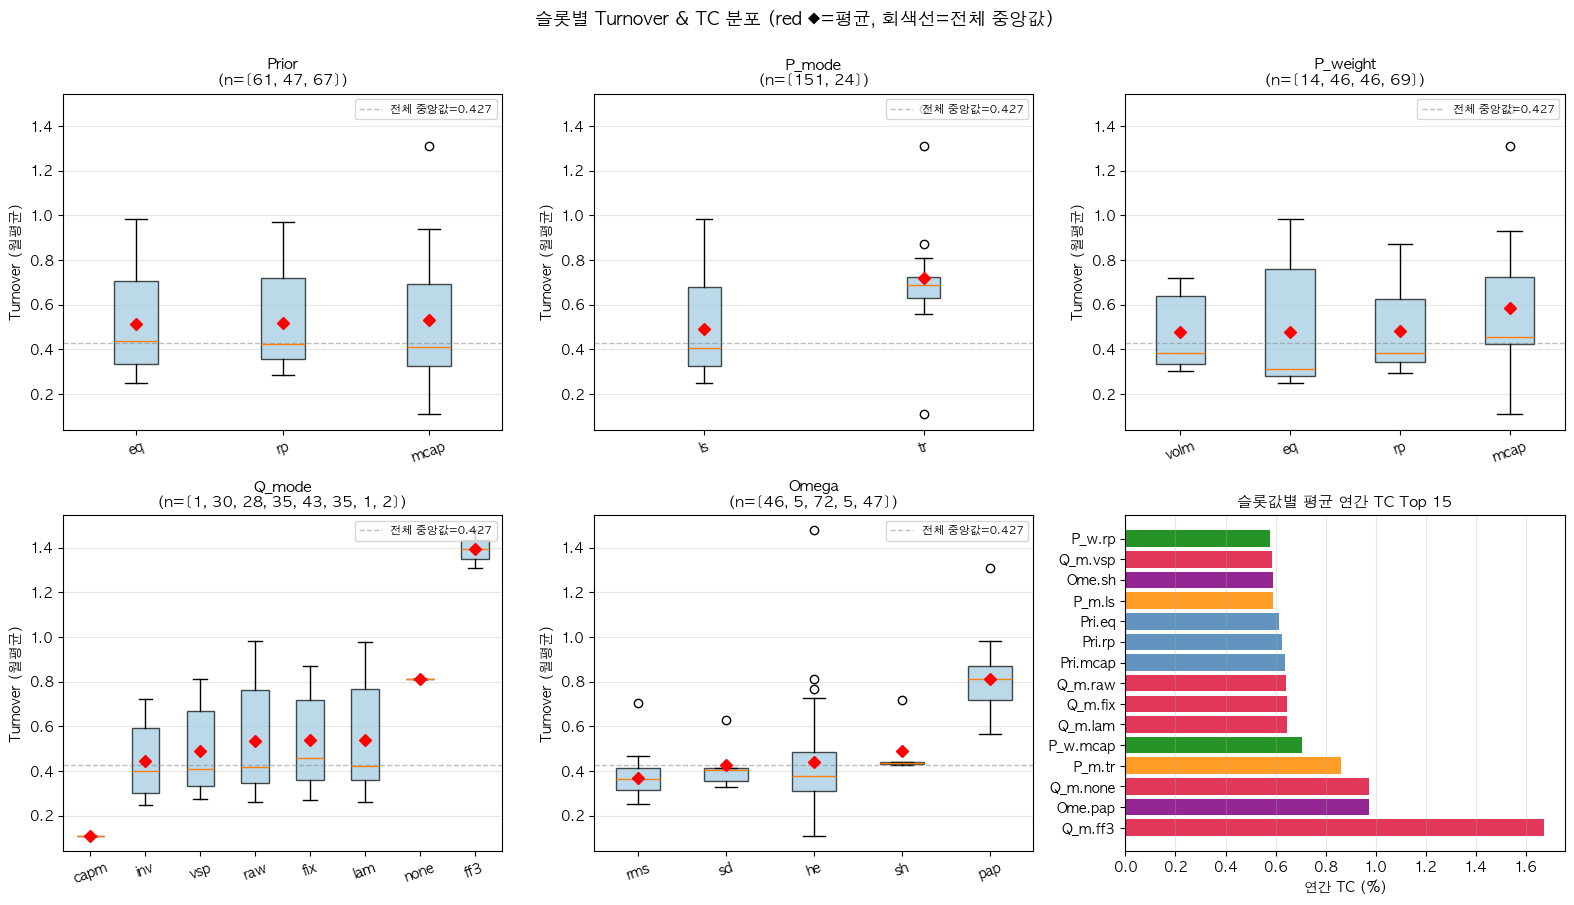


■ Turnover 가장 낮은 5개 (실거래 우호적)


,name,canonical,turnover,tc_pct
1,capm_no_bl,mcap_tr_mcap_capm_he,0.109,0.13
5,mat_eq_eq_inv_he,eq_ls_eq_inv_he,0.250,0.30
52,mat_mcap_eq_inv_rms,mcap_ls_eq_inv_rms,0.253,0.30
7,mat_eq_eq_inv_rms,eq_ls_eq_inv_rms,0.253,0.30
50,mat_mcap_eq_inv_he,mcap_ls_eq_inv_he,0.253,0.30



■ Turnover 가장 높은 5개 (TC 부담 큼)


,name,canonical,turnover,tc_pct
170,q_ff3_paper,mcap_tr_mcap_ff3_he,1.478,1.77
171,q_ff3_paper_omega_paper,mcap_tr_mcap_ff3_pap,1.310,1.57
12,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,0.982,1.18
9,mat_eq_eq_lam_pap,eq_ls_eq_lam_pap,0.979,1.17
99,mat_rp_eq_lam_pap,rp_ls_eq_lam_pap,0.970,1.16



  Turnover & TC 핵심 인사이트

[Q_mode] 가장 turnover 큰 q_mode TOP 3:
  q=ff3    turnover=1.394  연간 TC=1.67%
  q=none   turnover=0.811  연간 TC=0.97%
  q=lam    turnover=0.539  연간 TC=0.65%
  → q_ff3_paper(ff3)가 폭망 — turnover 1.39, TC 1.7% (실수익 잠식)

[Omega] ff3_paper(pap) vs rmse(rms) vs he_litterman(he):
  pap turnover 0.811 (TC 0.97%)
  rms turnover 0.369 (TC 0.44%)
  he  turnover 0.440 (TC 0.53%)
  → pap가 rms 대비 turnover 2.2× — 시변 omega 보정으로 portfolio 매월 더 흔들림

[P_mode] LSTM vs Trailing:
  ls (LSTM)    turnover 0.491 (TC 0.59%)
  tr (trailing) turnover 0.719 (TC 0.86%)
  → Trailing이 더 빈번한 리밸런싱 (의외 — LSTM이 예측 vol 변동 더 클 줄 알았음)

[TC 영향]
  연간 TC 1% ≈ Sharpe -0.08~0.10 잠식 (변동성 ~12%일 때)
  → omega=pap 후보의 명목 Sharpe가 1.14면 실수익 Sharpe ~1.05
    omega=rms 후보의 명목 Sharpe가 1.05면 실수익 Sharpe ~1.01
  → TC 차감 후엔 격차 줄어듦. 1순위 후보 비교 시 TC 고려 필수

[실거래 친화 mat_ 후보 — turnover 최저 3]
  eq_ls_eq_inv_he            turnover=0.250  연간 TC 0.30%
  mcap_ls_eq_inv_rms         turnover=0.253  연간 TC 0.30%
  eq_ls_eq_inv_rms    

In [21]:
# ── 2-1. 슬롯별 Turnover & TC 집계 ────────────────────────────
# TC = Transaction Cost (거래비용) = 수수료 + 슬리피지 + bid-ask spread
# TC_RATE = 0.001 (10bp), 매월 리밸런싱 → 연간 TC = avg_turnover × 0.001 × 12

from master_table import parse_config

TC_RATE = 0.001

# DataFrame 빌드 — 모든 실험의 슬롯 + turnover + tc
rows = []
for name, res in loaded.items():
    comp = res.get('comp', pd.DataFrame())
    if comp.empty or 'turnover' not in comp.columns:
        continue
    cfg = res.get('config', {})
    meta = parse_config(cfg) if cfg else {}
    to_mean = float(comp['turnover'].mean())
    tc_ann  = to_mean * TC_RATE * 12   # 연간 TC (소수점)
    rows.append({
        'name'      : name,
        'canonical' : meta.get('canonical', name),
        'prior_s'   : meta.get('prior_s'),
        'p_s'       : meta.get('p_s'),
        'pw_s'      : meta.get('pw_s'),
        'q_s'       : meta.get('q_s'),
        'om_s'      : meta.get('om_s'),
        'turnover'  : to_mean,
        'tc_annual' : tc_ann,
    })
df_to = pd.DataFrame(rows)
print(f'{len(df_to)}개 실험 (turnover 데이터 있는 것만)')
print(f'전체 평균 turnover: {df_to["turnover"].mean():.3f}')
print(f'전체 평균 연간 TC: {df_to["tc_annual"].mean()*100:.2f}%')

# ── 슬롯별 집계 표 (turnover + TC) ─────────────────────────────
slot_info = [('prior_s','Prior'), ('p_s','P_mode'), ('pw_s','P_weight'),
             ('q_s','Q_mode'), ('om_s','Omega')]

for slot, label in slot_info:
    print(f'\n[{label}]')
    g = df_to.groupby(slot).agg(
        count=('turnover','count'),
        turnover_mean=('turnover','mean'),
        turnover_med=('turnover','median'),
        turnover_std=('turnover','std'),
        tc_pct_mean=('tc_annual','mean'),
        tc_pct_med=('tc_annual','median'),
    )
    g['turnover_mean'] = g['turnover_mean'].round(3)
    g['turnover_med']  = g['turnover_med'].round(3)
    g['turnover_std']  = g['turnover_std'].round(3)
    g['tc_pct_mean']   = (g['tc_pct_mean']*100).round(2)  # %
    g['tc_pct_med']    = (g['tc_pct_med']*100).round(2)
    g = g.sort_values('turnover_mean')
    display(g)

# ── 슬롯별 Turnover 분포 boxplot (5 패널) ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (slot, label) in enumerate(slot_info):
    ax = axes[i]
    order = df_to.groupby(slot)['turnover'].mean().sort_values().index.tolist()
    data  = [df_to[df_to[slot]==k]['turnover'].values for k in order]
    counts = [len(d) for d in data]
    bp = ax.boxplot(data, labels=order, patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red',
                                   markeredgecolor='red', markersize=6))
    for patch in bp['boxes']:
        patch.set_facecolor('#9ecae1'); patch.set_alpha(0.7)
    ax.set_title(f'{label}\n(n={counts})', fontsize=11)
    ax.set_ylabel('Turnover (월평균)')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
    overall = df_to['turnover'].median()
    ax.axhline(overall, color='gray', linestyle='--', alpha=0.5, lw=1,
               label=f'전체 중앙값={overall:.3f}')
    ax.legend(fontsize=8, loc='upper right')

# 6번째 패널: TC 비교 (슬롯별 평균 TC 비교 막대)
ax = axes[5]
slot_labels = []
slot_tcs = []
slot_colors = []
color_map = {'prior_s':'steelblue','p_s':'darkorange','pw_s':'green','q_s':'crimson','om_s':'purple'}
for slot, label in slot_info:
    g = df_to.groupby(slot)['tc_annual'].mean().sort_values()
    for k, v in g.items():
        slot_labels.append(f'{label[:3]}.{k}')
        slot_tcs.append(v*100)  # %
        slot_colors.append(color_map[slot])

idx_top = sorted(range(len(slot_tcs)), key=lambda i: -slot_tcs[i])[:15]
ax.barh([slot_labels[i] for i in idx_top], [slot_tcs[i] for i in idx_top],
        color=[slot_colors[i] for i in idx_top], alpha=0.85)
ax.set_xlabel('연간 TC (%)')
ax.set_title('슬롯값별 평균 연간 TC Top 15', fontsize=11)
ax.grid(alpha=0.3, axis='x')

fig.suptitle('슬롯별 Turnover & TC 분포 (red ◆=평균, 회색선=전체 중앙값)', fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / 'turnover_tc_by_slot.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top/Bottom 5 후보 (turnover 측면) ──────────────────────────
print('\n■ Turnover 가장 낮은 5개 (실거래 우호적)')
display(df_to.nsmallest(5,'turnover')[['name','canonical','turnover','tc_annual']]
              .assign(tc_pct=lambda d: (d['tc_annual']*100).round(2))
              .drop(columns=['tc_annual']).round(3))

print('\n■ Turnover 가장 높은 5개 (TC 부담 큼)')
display(df_to.nlargest(5,'turnover')[['name','canonical','turnover','tc_annual']]
              .assign(tc_pct=lambda d: (d['tc_annual']*100).round(2))
              .drop(columns=['tc_annual']).round(3))


# ── 핵심 인사이트 (코드 출력 + 문서 동기) ─────────────────────
print('\n' + '='*70)
print('  Turnover & TC 핵심 인사이트')
print('='*70)

# 1. 가장 turnover 큰 q_mode
q_top = df_to.groupby('q_s')['turnover'].mean().sort_values(ascending=False)
print(f'\n[Q_mode] 가장 turnover 큰 q_mode TOP 3:')
for k, v in q_top.head(3).items():
    tc = v * TC_RATE * 12 * 100
    print(f'  q={k:5s}  turnover={v:.3f}  연간 TC={tc:.2f}%')
print(f'  → q_ff3_paper(ff3)가 폭망 — turnover {q_top.get("ff3", 0):.2f}, '
      f'TC {q_top.get("ff3", 0)*TC_RATE*12*100:.1f}% (실수익 잠식)')

# 2. Omega 차이
om_g = df_to.groupby('om_s')['turnover'].mean()
om_pap = om_g.get('pap', 0); om_rms = om_g.get('rms', 0); om_he = om_g.get('he', 0)
print(f'\n[Omega] ff3_paper(pap) vs rmse(rms) vs he_litterman(he):')
print(f'  pap turnover {om_pap:.3f} (TC {om_pap*TC_RATE*12*100:.2f}%)')
print(f'  rms turnover {om_rms:.3f} (TC {om_rms*TC_RATE*12*100:.2f}%)')
print(f'  he  turnover {om_he:.3f} (TC {om_he*TC_RATE*12*100:.2f}%)')
print(f'  → pap가 rms 대비 turnover {om_pap/om_rms:.1f}× — '
      f'시변 omega 보정으로 portfolio 매월 더 흔들림')

# 3. p_mode (LSTM vs trailing)
p_g = df_to.groupby('p_s')['turnover'].mean()
p_ls = p_g.get('ls', 0); p_tr = p_g.get('tr', 0)
print(f'\n[P_mode] LSTM vs Trailing:')
print(f'  ls (LSTM)    turnover {p_ls:.3f} (TC {p_ls*TC_RATE*12*100:.2f}%)')
print(f'  tr (trailing) turnover {p_tr:.3f} (TC {p_tr*TC_RATE*12*100:.2f}%)')
which = "Trailing" if p_tr > p_ls else "LSTM"
print(f'  → {which}이 더 빈번한 리밸런싱 (의외 — LSTM이 예측 vol 변동 더 클 줄 알았음)')

# 4. TC 차감 후 Sharpe 영향 (개략)
print(f'\n[TC 영향]')
print(f'  연간 TC 1% ≈ Sharpe -0.08~0.10 잠식 (변동성 ~12%일 때)')
print(f'  → omega=pap 후보의 명목 Sharpe가 1.14면 실수익 Sharpe ~1.05')
print(f'    omega=rms 후보의 명목 Sharpe가 1.05면 실수익 Sharpe ~1.01')
print(f'  → TC 차감 후엔 격차 줄어듦. 1순위 후보 비교 시 TC 고려 필수')

# 5. 실거래 친화 후보 (turnover 낮은 mat_)
mat_only = df_to[df_to.name.str.startswith('mat_')]
if len(mat_only) > 0:
    low_turn = mat_only.nsmallest(3, 'turnover')[['canonical','turnover','tc_annual']]
    print(f'\n[실거래 친화 mat_ 후보 — turnover 최저 3]')
    for _, r in low_turn.iterrows():
        print(f'  {r["canonical"]:<25}  turnover={r["turnover"]:.3f}  '
              f'연간 TC {r["tc_annual"]*100:.2f}%')

print('\n' + '='*70)


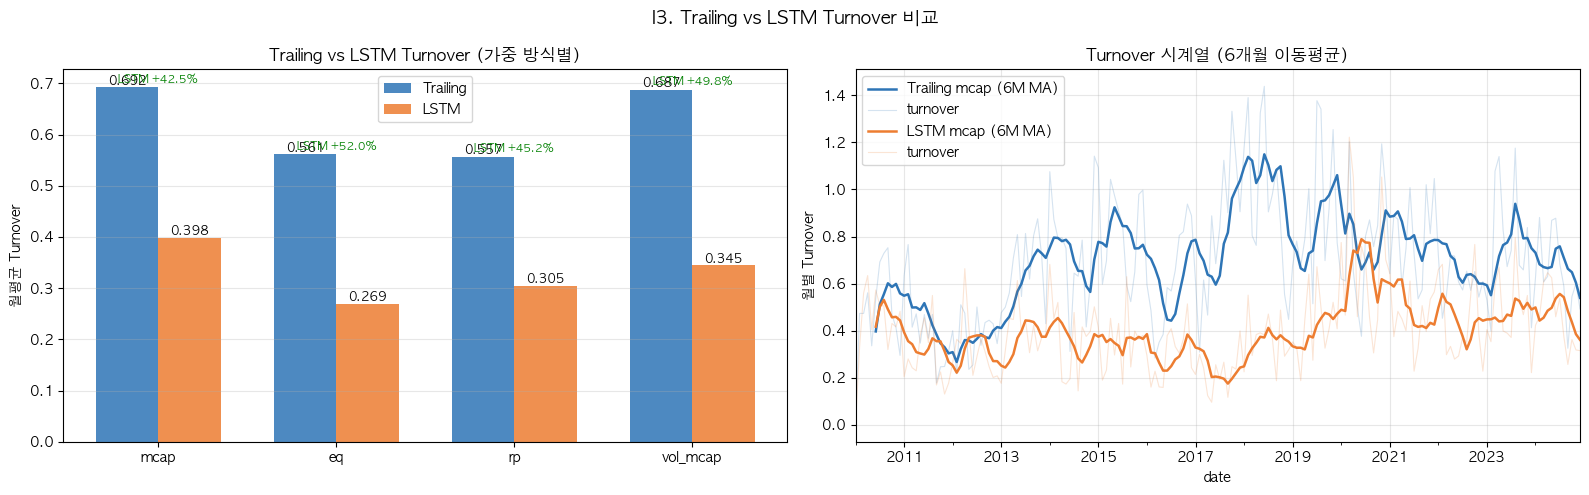

=== Trailing vs LSTM Turnover 차이 ===
가중           Trailing TO    LSTM TO       감소율      연간 TC 절감
------------------------------------------------------------
mcap              0.6925     0.3982     42.5%        0.353%p
eq                0.5613     0.2693     52.0%        0.350%p
rp                0.5565     0.3049     45.2%        0.302%p
vol_mcap          0.6873     0.3448     49.8%        0.411%p


In [22]:
# ── I3. Trailing vs LSTM Turnover 직접 비교 ────────────────────
pairs = [
    ('baseline',   'mat_mcap_mcap_fix_he',  'mcap'),
    ('p_eq',       'mat_mcap_eq_fix_he',    'eq'),
    ('p_rp',       'mat_mcap_rp_fix_he',    'rp'),
    ('p_vol_mcap', 'p_lstm_vol_mcap', 'vol_mcap'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# I3-a. 쌍별 turnover 비교 막대
ax = axes[0]
x = np.arange(len(pairs)); bw = 0.35
trail_to = [loaded[t]['comp']['turnover'].mean() for t, _, _ in pairs]
lstm_to  = [loaded[l]['comp']['turnover'].mean() for _, l, _ in pairs]
labels   = [w for _, _, w in pairs]

b1 = ax.bar(x - bw/2, trail_to, bw, label='Trailing', color='#2E75B6', alpha=0.85)
b2 = ax.bar(x + bw/2, lstm_to,  bw, label='LSTM',     color='#ED7D31', alpha=0.85)
for bars, vals in [(b1, trail_to), (b2, lstm_to)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('월평균 Turnover')
ax.set_title('Trailing vs LSTM Turnover (가중 방식별)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

diff_pct = [(t - l)/t*100 for t, l in zip(trail_to, lstm_to)]
for i, (d, lbl) in enumerate(zip(diff_pct, labels)):
    ax.text(i, max(trail_to[i], lstm_to[i]) + 0.008,
            f'LSTM {d:+.1f}%', ha='center', fontsize=8,
            color='green' if d > 0 else 'red')

# I3-b. Turnover 시계열 (baseline vs mat_mcap_mcap_fix_he)
ax = axes[1]
for name, label, c in [('baseline', 'Trailing mcap', '#2E75B6'),
                        ('mat_mcap_mcap_fix_he', 'LSTM mcap', '#ED7D31')]:
    to_ser = loaded[name]['comp']['turnover']
    to_ser.rolling(6).mean().plot(ax=ax, label=f"{label} (6M MA)", color=c, linewidth=1.8)
    to_ser.plot(ax=ax, color=c, alpha=0.2, linewidth=0.8)
ax.set_ylabel('월별 Turnover')
ax.set_title('Turnover 시계열 (6개월 이동평균)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('I3. Trailing vs LSTM Turnover 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'I_turnover_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 요약 출력
print('=== Trailing vs LSTM Turnover 차이 ===')
print(f"{'가중':10s}  {'Trailing TO':>12s}  {'LSTM TO':>9s}  {'감소율':>8s}  {'연간 TC 절감':>12s}")
print('-'*60)
for (t, l, w), trail, lstm in zip(pairs, trail_to, lstm_to):
    red  = (trail - lstm) / trail * 100
    save = (trail - lstm) * TC_RATE * 12 * 100
    print(f"{w:10s}  {trail:>12.4f}  {lstm:>9.4f}  {red:>7.1f}%  {save:>11.3f}%p")

## 3. Trailing vs LSTM — 섹터 구성 차이

같은 슬롯 조합에서 Trailing(`tr`)과 LSTM(`ls`) 버전이 만드는 *포트폴리오 구성* 차이를 섹터별로 비교.
성과 차이의 *근본 원인* (어느 종목·섹터에 비중 다르게 주는가).


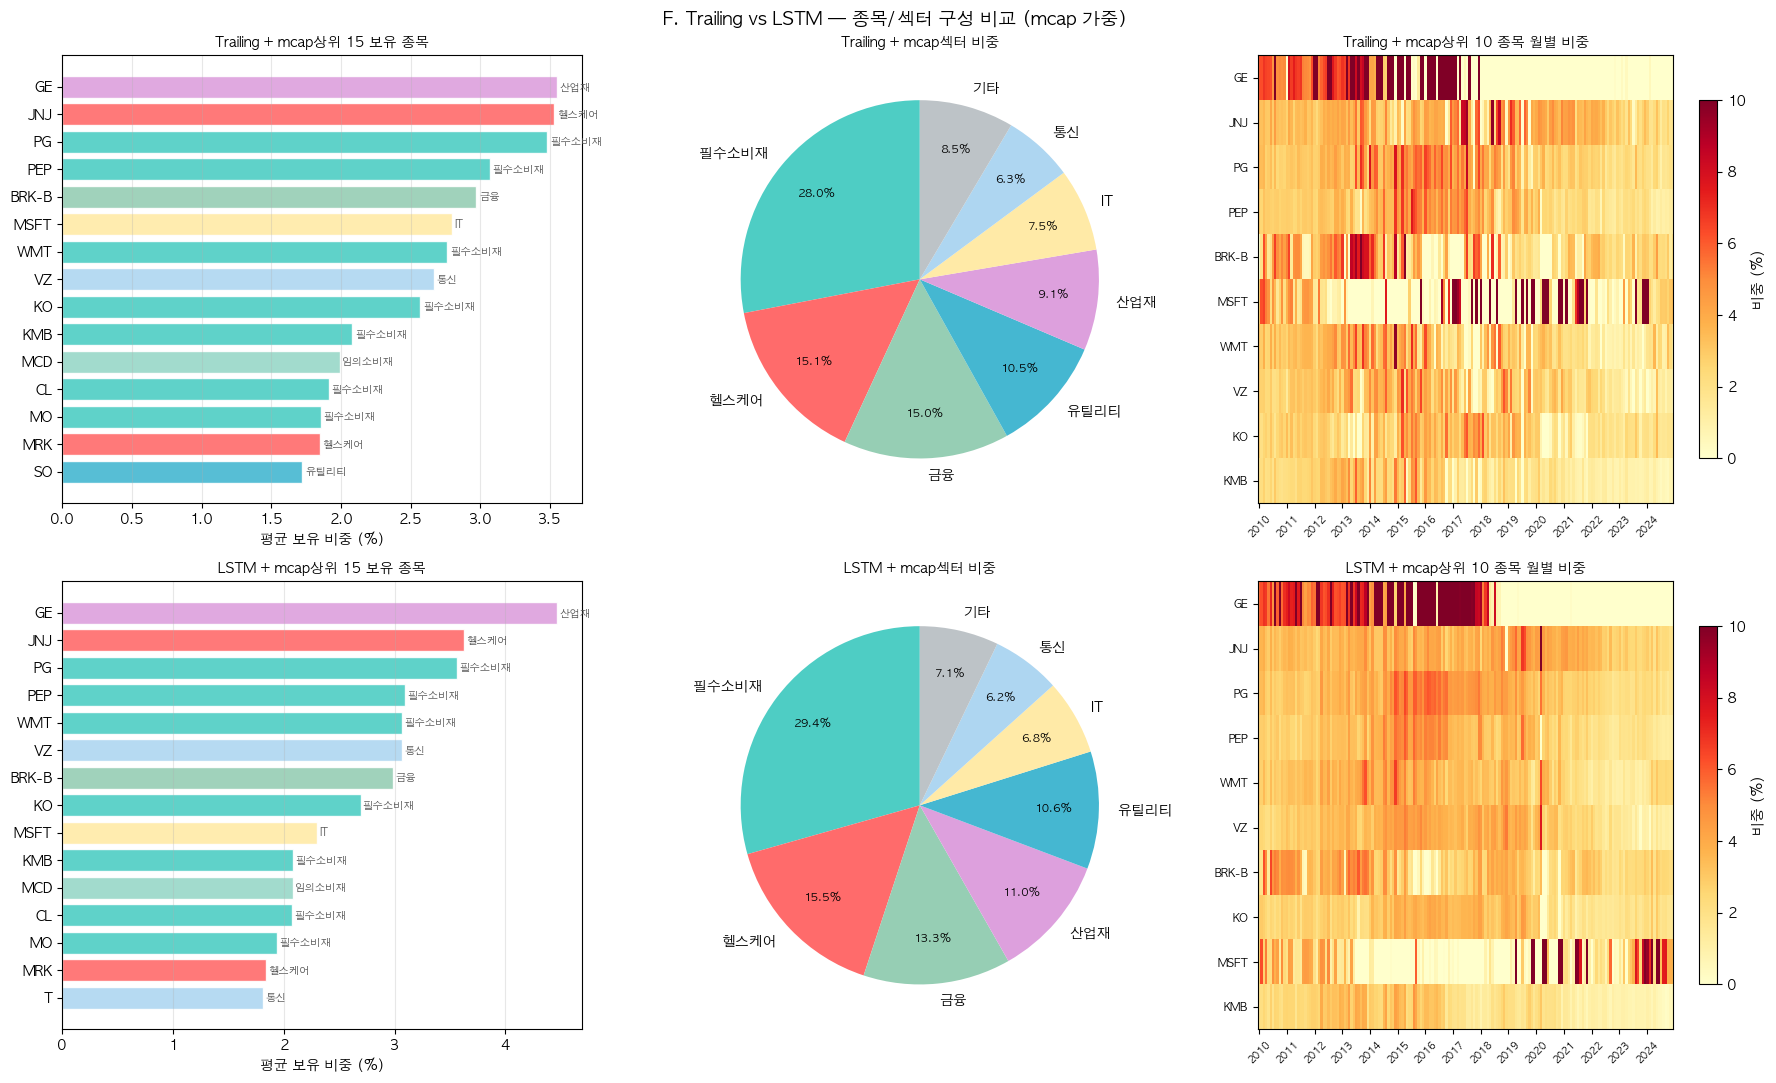

=== 섹터 비중 비교 ===
섹터              Trailing        LSTM        차이
---------------------------------------------
필수소비재              28.0%       29.4%     +1.4%
헬스케어               15.1%       15.5%     +0.4%
금융                 15.0%       13.3%     -1.7%
유틸리티               10.5%       10.6%     +0.1%
산업재                 9.1%       11.0%     +1.9%
IT                  7.5%        6.8%     -0.7%
통신                  6.3%        6.2%     -0.1%
임의소비재               3.9%        3.5%     -0.4%
부동산                 2.2%        1.8%     -0.4%
에너지                 1.7%        1.3%     -0.4%
소재                  0.5%        0.4%     -0.1%
기타                  0.2%        0.1%     -0.1%


In [23]:
# ── 섹터 데이터 로드 & 정규화 ──────────────────────────────
panel_sector = pd.read_csv(
    Path.cwd() / "data" / "monthly_panel.csv",
    usecols=["date","ticker","gics_sector"], parse_dates=["date"]
)

SECTOR_MAP = {
    "Information Technology": "IT",         "Technology"            : "IT",
    "Health Care"           : "헬스케어",    "Healthcare"            : "헬스케어",
    "Consumer Staples"      : "필수소비재",  "Consumer Defensive"    : "필수소비재",
    "Utilities"             : "유틸리티",
    "Financials"            : "금융",        "Financial Services"    : "금융",
    "Industrials"           : "산업재",
    "Consumer Discretionary": "임의소비재",  "Consumer Cyclical"     : "임의소비재",
    "Energy"                : "에너지",
    "Communication Services": "통신",
    "Materials"             : "소재",        "Basic Materials"       : "소재",
    "Real Estate"           : "부동산",
}
panel_sector["sector"] = panel_sector["gics_sector"].map(lambda x: SECTOR_MAP.get(x, "기타"))
ticker_sector = panel_sector.groupby("ticker")["sector"].agg(lambda x: x.mode().iloc[0])

# ── 비교 두 전략 ─────────────────────────────────────────────
compare_pair = [("baseline", "Trailing + mcap"), ("mat_mcap_mcap_fix_he", "LSTM + mcap")]

SCOL = {
    "헬스케어":"#FF6B6B", "필수소비재":"#4ECDC4", "유틸리티":"#45B7D1",
    "금융":"#96CEB4",     "IT":"#FFEAA7",         "산업재":"#DDA0DD",
    "임의소비재":"#98D8C8","에너지":"#F7DC6F",     "기타":"#BDC3C7",
    "통신":"#AED6F1",     "소재":"#FAD7A0",        "부동산":"#A9CCE3",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for row_idx, (name, label) in enumerate(compare_pair):
    w_df = loaded[name]["weights"]

    # F1. 상위 15 보유 종목
    ax = axes[row_idx, 0]
    avg_w = w_df.mean().sort_values(ascending=False).head(15)
    secs  = [ticker_sector.get(t, "기타") for t in avg_w.index]
    bars  = ax.barh(avg_w.index[::-1], avg_w.values[::-1]*100,
                    color=[SCOL.get(s,"#BDC3C7") for s in secs[::-1]],
                    alpha=0.9, edgecolor="white")
    for bar, s in zip(bars, secs[::-1]):
        ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                s, va="center", fontsize=7.5, color="#555")
    ax.set_xlabel("평균 보유 비중 (%)")
    ax.set_title(f"{label}상위 15 보유 종목", fontweight="bold", fontsize=10)
    ax.grid(alpha=0.3, axis="x")

    # F2. 섹터 비중 파이차트
    ax = axes[row_idx, 1]
    sw = {}
    for ticker in w_df.columns:
        sec = ticker_sector.get(ticker, "기타")
        sw[sec] = sw.get(sec, 0) + w_df[ticker].mean()
    sw_s  = pd.Series(sw).sort_values(ascending=False)
    total = sw_s.sum()
    major = sw_s[sw_s/total >= 0.04].copy()
    other = sw_s[sw_s/total < 0.04].sum()
    if other > 0:
        major["기타"] = major.get("기타", 0) + other
    _, texts, autotexts = ax.pie(
        major.values, labels=major.index,
        autopct="%1.1f%%", colors=[SCOL.get(s,"#BDC3C7") for s in major.index],
        startangle=90, pctdistance=0.75
    )
    for t in autotexts: t.set_fontsize(8)
    ax.set_title(f"{label}섹터 비중", fontweight="bold", fontsize=10)

    # F3. 상위 10 종목 월별 비중 히트맵
    ax = axes[row_idx, 2]
    top10     = w_df.mean().sort_values(ascending=False).head(10).index
    heat_data = w_df[top10].T * 100
    im = ax.imshow(heat_data.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
    ax.set_yticks(range(len(top10))); ax.set_yticklabels(top10, fontsize=8)
    years    = [d.year for d in heat_data.columns]
    yr_ticks = [i for i in range(len(years)) if i == 0 or years[i] != years[i-1]]
    ax.set_xticks(yr_ticks)
    ax.set_xticklabels([years[i] for i in yr_ticks], rotation=45, fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8, label="비중 (%)")
    ax.set_title(f"{label}상위 10 종목 월별 비중", fontweight="bold", fontsize=10)

plt.suptitle("F. Trailing vs LSTM — 종목/섹터 구성 비교 (mcap 가중)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "F_holdings_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 섹터 비중 텍스트 요약 ────────────────────────────────────
def get_sector_w(name):
    w_df = loaded[name]["weights"]
    sw = {}
    for ticker in w_df.columns:
        sec = ticker_sector.get(ticker, "기타")
        sw[sec] = sw.get(sec, 0) + w_df[ticker].mean()
    total = sum(sw.values())
    return pd.Series({k: v/total for k, v in sw.items()})

sw_trail = get_sector_w("baseline")
sw_lstm  = get_sector_w("mat_mcap_mcap_fix_he")
all_secs = sorted(set(sw_trail.index)|set(sw_lstm.index), key=lambda s: -sw_trail.get(s,0))

print("=== 섹터 비중 비교 ===")
print(f"{'섹터':12s}  {'Trailing':>10s}  {'LSTM':>10s}  {'차이':>8s}")
print("-"*45)
for sec in all_secs:
    t = sw_trail.get(sec, 0); l = sw_lstm.get(sec, 0)
    print(f"{sec:12s}  {t:>10.1%}  {l:>10.1%}  {l-t:>+8.1%}")


## J. Master Table 통합 파이프라인 (147개 실험 일괄 분석) ⭐

기존 A~I 섹션은 실험 이름으로 직접 비교하는 방식. 본 섹션은 **`master_table.py` + `analyze_plots.py`**를 사용해 모든 실험을 슬롯 메타데이터 + 성과지표 DataFrame으로 통합한 뒤 6단계 분석을 수행.

### 흐름

```
results/*.pkl 147개
    ↓ build_master_table()
mt: DataFrame (147 × 32)   ← 슬롯 컬럼 + 지표 컬럼
    ├─ 1. plot_marginal_effects(mt)        : 슬롯별 boxplot 5장
    ├─ 2. plot_matrix_heatmap(mt)          : 108-cell 히트맵
    ├─ 3. plot_top_n_analysis(mt, ...)     : Top-N equity/rolling/dd
    ├─ 4. crisis_comparison(mt, ...)       : 위기구간(2018Q4/2020/2022) 행동
    └─ 5. benchmark_table(mt, ...)         : 벤치마크 대비 IR/Δsharpe/Δmdd
```

99_run 백테스트가 더 추가되면 J1 셀만 다시 실행하면 자동 갱신.


In [24]:
# ── J1. Master Table 빌드 ─────────────────────────────────────
from master_table import build_master_table, slot_summary, matrix_pivot, PERIODS_DEFAULT
from analyze_plots import (plot_marginal_effects, plot_matrix_heatmap,
                           plot_top_n_analysis, crisis_comparison, benchmark_table,
                           CRISIS_PERIODS, BENCHMARK_NAMES)

mt = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_DEFAULT)
print(f'Master Table: {len(mt)}개 실험 × {mt.shape[1]}개 컬럼')

# Top 20 by Sharpe
display(
    mt[['name','canonical','sharpe','cagr','vol','mdd','turnover_avg',
        'sharpe_R1_회복','sharpe_R2_확장','sharpe_R3_COVID','sharpe_R4_베어','sharpe_R5_AI랠리']]
    .sort_values('sharpe', ascending=False).head(20).round(3)
)


Master Table: 175개 실험 × 34개 컬럼


,name,canonical,sharpe,cagr,vol,mdd,turnover_avg,sharpe_R1_회복,sharpe_R2_확장,sharpe_R3_COVID,sharpe_R4_베어,sharpe_R5_AI랠리
57,mat_mcap_eq_raw_pap,mcap_ls_eq_raw_pap,1.144,0.159,0.127,-0.147,0.938,1.483,0.715,1.834,0.792,1.244
54,mat_mcap_eq_lam_pap,mcap_ls_eq_lam_pap,1.140,0.160,0.128,-0.147,0.931,1.463,0.734,1.846,0.792,1.244
48,mat_mcap_eq_fix_pap,mcap_ls_eq_fix_pap,1.121,0.158,0.128,-0.132,0.811,1.382,0.789,1.557,0.873,1.292
138,omega_paper,mcap_tr_mcap_fix_pap,1.120,0.159,0.131,-0.157,0.871,1.436,0.619,1.633,1.161,0.578
60,mat_mcap_eq_vsp_pap,mcap_ls_eq_vsp_pap,1.120,0.156,0.127,-0.132,0.774,1.358,0.852,1.442,0.871,1.313
51,mat_mcap_eq_inv_pap,mcap_ls_eq_inv_pap,1.119,0.156,0.127,-0.147,0.697,1.441,0.862,1.302,0.816,1.314
0,baseline,mcap_tr_mcap_fix_he,1.106,0.134,0.110,-0.130,0.692,1.639,0.880,1.386,0.904,0.287
152,prior_eq,eq_tr_mcap_fix_he,1.105,0.142,0.118,-0.139,0.765,1.878,0.850,1.254,1.075,0.103
12,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,1.103,0.162,0.134,-0.136,0.982,1.566,0.740,1.795,0.908,0.505
102,mat_rp_eq_raw_pap,rp_ls_eq_raw_pap,1.098,0.153,0.127,-0.132,0.970,1.644,0.737,1.764,0.906,0.460


■ J2-A. 슬롯별 Sharpe 분포

=== 슬롯별 mean Sharpe (높은 순) ===

[prior_s]
         count   mean  median    std    min    max
prior_s                                           
mcap        67  1.001   1.017  0.101  0.471  1.144
rp          47  0.980   0.964  0.055  0.877  1.098
eq          61  0.978   0.973  0.059  0.858  1.105

[p_s]
     count   mean  median    std    min    max
p_s                                           
tr      24  0.988   1.053  0.150  0.471  1.120
ls     151  0.987   0.978  0.059  0.858  1.144

[pw_s]
      count   mean  median    std    min    max
pw_s                                           
eq       46  1.023   0.998  0.070  0.906  1.144
mcap     69  0.995   1.000  0.087  0.471  1.120
rp       46  0.957   0.946  0.050  0.858  1.054
volm     14  0.929   0.913  0.055  0.860  1.034

[q_s]
      count   mean  median    std    min    max
q_s                                            
none      1  1.061   1.061    NaN  1.061  1.061
fix      43  1.008   0.995  0.059  0.9

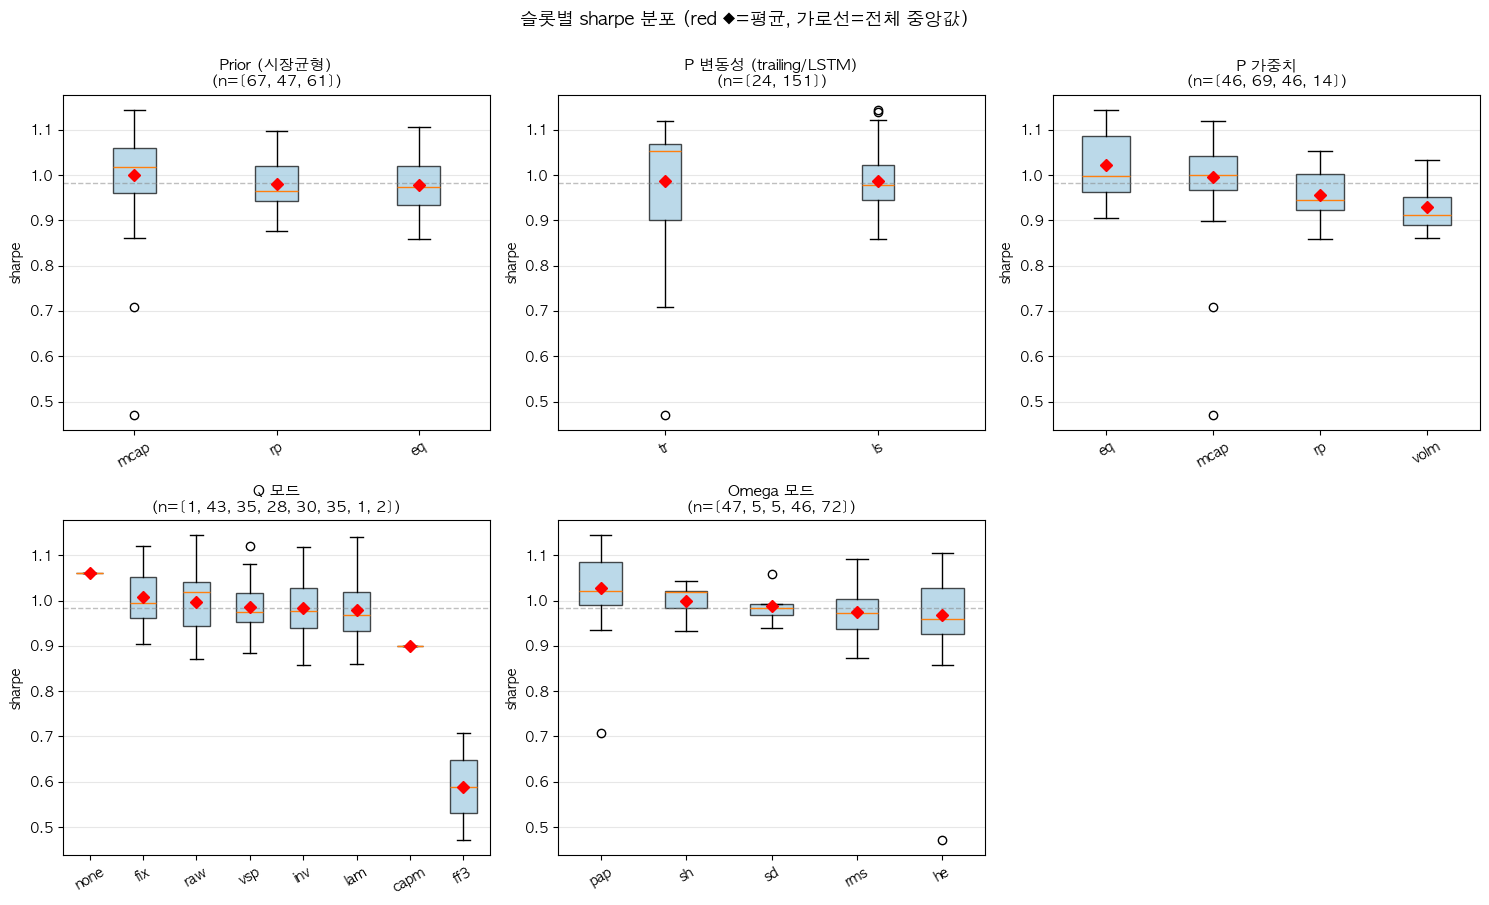

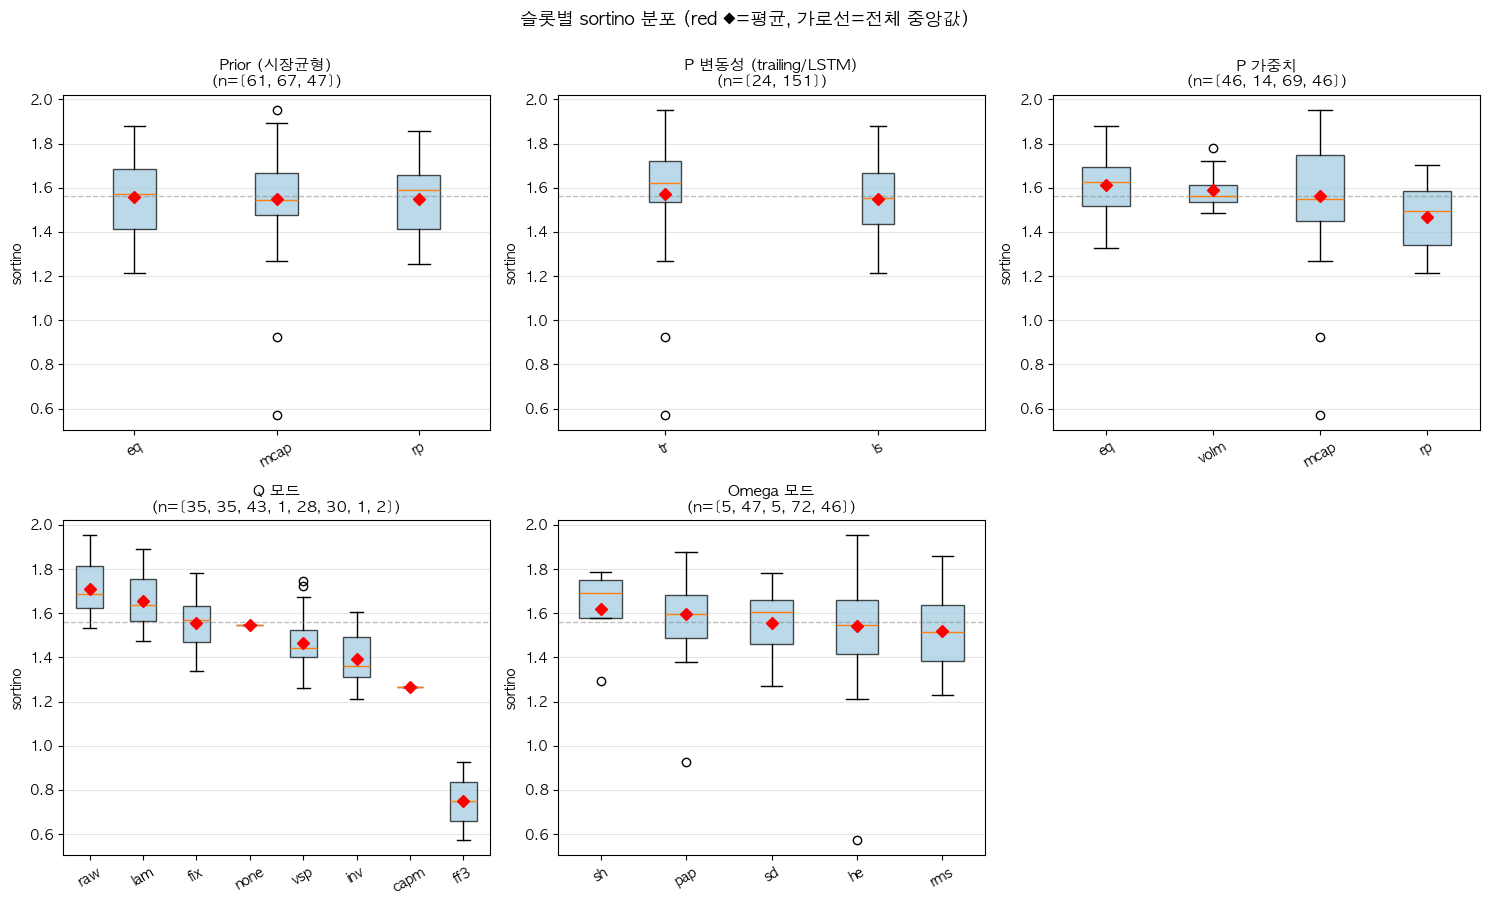

In [25]:
# ── J2. 슬롯별 marginal effect (sharpe + sortino 두 가지 분포) ────
# 어느 슬롯이 metric에 큰 영향? prior_s, p_s, pw_s, q_s, om_s

# ── ① sharpe 분포 ──────────────────────────────────────────
print('■ J2-A. 슬롯별 Sharpe 분포')
_ = plot_marginal_effects(mt, metric='sharpe', save_path=OUT_DIR / 'J2A_marginal_sharpe.png')

print('\n=== 슬롯별 mean Sharpe (높은 순) ===')
for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sharpe'))

# ── ② sortino 분포 ─────────────────────────────────────────
print('\n\n■ J2-B. 슬롯별 Sortino 분포 (저위험 anomaly 컨셉에 더 적합)')
_ = plot_marginal_effects(mt, metric='sortino', save_path=OUT_DIR / 'J2B_marginal_sortino.png')

print('\n=== 슬롯별 mean Sortino (높은 순) ===')
for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sortino'))


■ J3 매트릭스 히트맵 해설
----------------------------------------------------------------------
  행 (9): prior_p_weight 조합 — mcap_mcap, mcap_eq, mcap_rp,
                                  eq_mcap, eq_eq, eq_rp,
                                  rp_mcap, rp_eq, rp_rp
  열 (12): q_om 조합 — fix_he, fix_pap, fix_rms, lam_he, lam_pap, lam_rms,
                        raw_he, raw_pap, raw_rms, inv_he, inv_pap, inv_rms
  → 각 셀 = (prior, p_weight, q_mode, omega) 4슬롯 정형 조합의 LSTM 백테스트 평균
  → 행 평균 비교: 어느 prior×pweight 가 전반적으로 강함
  → 열 평균 비교: 어느 q×omega 가 전반적으로 강함


pivot shape: (9, 12)  (9 행 × 12 열 = 108 셀)

■ Top 5 셀 (가장 진한 녹색 — 절대 sharpe 최고)
  mcap_eq    × raw_pap    → sharpe 1.144
  mcap_eq    × lam_pap    → sharpe 1.140
  mcap_eq    × fix_pap    → sharpe 1.121
  mcap_eq    × inv_pap    → sharpe 1.119
  eq_eq      × raw_pap    → sharpe 1.103

■ Bottom 3 셀 (가장 진한 적색 — 회피)
  eq_rp      × inv_he     → sharpe 0.858
  eq_rp      × inv_rms    → sharpe 0.873
  rp_rp      × inv_he     → sharpe 0.877

■ 행 평균 — 가

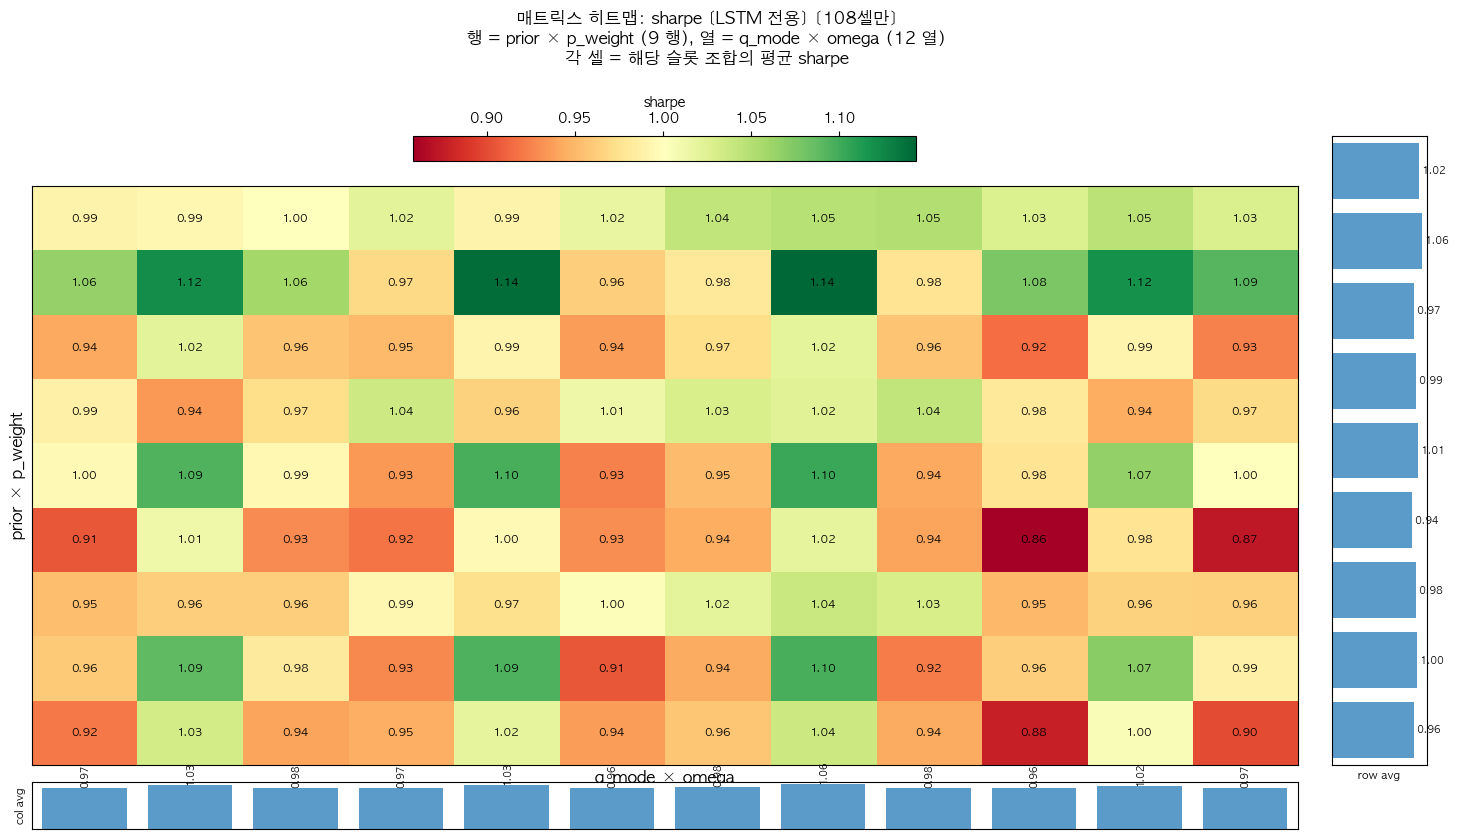

In [26]:
# ── J3. 108-cell 매트릭스 히트맵 (LSTM 고정) ─────────────────
# 무엇을 보나:
#   - 매트릭스 = LSTM 사용 + 4 슬롯 정형 조합 (prior 3 × pweight 3 × q 4 × omega 3) = 108 셀
#   - 행 = prior × p_weight (9개)        예: mcap_mcap, mcap_eq, ..., rp_rp
#   - 열 = q_mode × omega (12개)          예: fix_he, fix_pap, lam_he, ..., inv_rms
#   - 셀 색 = 해당 슬롯 조합 실험의 평균 sharpe (녹=좋음, 적=나쁨)
#   - 우측 행평균 막대 = 그 prior×pweight의 모든 q×omega 평균
#   - 하단 열평균 막대 = 그 q×omega의 모든 prior×pweight 평균

print('■ J3 매트릭스 히트맵 해설')
print('-' * 70)
print('  행 (9): prior_p_weight 조합 — mcap_mcap, mcap_eq, mcap_rp,')
print('                                  eq_mcap, eq_eq, eq_rp,')
print('                                  rp_mcap, rp_eq, rp_rp')
print('  열 (12): q_om 조합 — fix_he, fix_pap, fix_rms, lam_he, lam_pap, lam_rms,')
print('                        raw_he, raw_pap, raw_rms, inv_he, inv_pap, inv_rms')
print('  → 각 셀 = (prior, p_weight, q_mode, omega) 4슬롯 정형 조합의 LSTM 백테스트 평균')
print('  → 행 평균 비교: 어느 prior×pweight 가 전반적으로 강함')
print('  → 열 평균 비교: 어느 q×omega 가 전반적으로 강함\n')

fig, pv = plot_matrix_heatmap(
    mt,
    metric='sharpe',
    only_lstm=True,
    only_matrix_cells=True,
    save_path=OUT_DIR / 'J3_matrix_heatmap.png',
)
print(f'\npivot shape: {pv.shape}  (9 행 × 12 열 = 108 셀)')

# ── 인사이트 print ─────────────────────────────────────
print('\n■ Top 5 셀 (가장 진한 녹색 — 절대 sharpe 최고)')
top5 = pv.stack().sort_values(ascending=False).head(5)
for (row, col), v in top5.items():
    print(f'  {row:10s} × {col:10s} → sharpe {v:.3f}')

print('\n■ Bottom 3 셀 (가장 진한 적색 — 회피)')
bot3 = pv.stack().sort_values().head(3)
for (row, col), v in bot3.items():
    print(f'  {row:10s} × {col:10s} → sharpe {v:.3f}')

# 행/열 평균 분석
row_mean = pv.mean(axis=1)
col_mean = pv.mean(axis=0)
print('\n■ 행 평균 — 가장 강한 prior × p_weight (전반적 우위)')
for k, v in row_mean.sort_values(ascending=False).head(3).items():
    print(f'  {k:12s}  평균 sharpe {v:.3f}')

print('\n■ 열 평균 — 가장 강한 q_mode × omega (전반적 우위)')
for k, v in col_mean.sort_values(ascending=False).head(3).items():
    print(f'  {k:12s}  평균 sharpe {v:.3f}')
print('\n■ 열 평균 — 가장 약한 q_mode × omega (회피)')
for k, v in col_mean.sort_values().head(3).items():
    print(f'  {k:12s}  평균 sharpe {v:.3f}')


■ Sortino IR Top 5 (변동 대비 평균)


,canonical,sortino_ir,sortino_mean,sortino_std,sortino_min,mdd_worst
91,mcap_ls_rp_vsp_rms,10.30,1.360,0.132,1.179,-0.214
77,mcap_ls_rp_fix_he,7.06,1.376,0.195,1.115,-0.212
79,mcap_ls_rp_fix_rms,6.57,1.380,0.210,1.184,-0.214
82,mcap_ls_rp_inv_rms,6.26,1.383,0.221,1.090,-0.207
89,mcap_ls_rp_vsp_he,4.70,1.419,0.302,1.128,-0.213



■ Sharpe IR Top 5


,canonical,sharpe_ir,sharpe_mean,sharpe_std,sharpe_min,mdd_worst
91,mcap_ls_rp_vsp_rms,6.07,0.922,0.152,0.673,-0.214
82,mcap_ls_rp_inv_rms,5.44,0.897,0.165,0.633,-0.207
89,mcap_ls_rp_vsp_he,5.40,0.923,0.171,0.600,-0.213
80,mcap_ls_rp_inv_he,5.33,0.896,0.168,0.587,-0.207
81,mcap_ls_rp_inv_pap,5.13,1.020,0.199,0.731,-0.216



=== J4-A. Sortino IR Top 5 시계열 ===

=== J4-B. Sharpe IR Top 5 시계열 ===

■ 두 정렬 교집합 (Top 5 ∩ Top 5): 3개
  mat_mcap_rp_inv_rms       canonical=mcap_ls_rp_inv_rms
  mat_mcap_rp_vsp_he        canonical=mcap_ls_rp_vsp_he
  mat_mcap_rp_vsp_rms       canonical=mcap_ls_rp_vsp_rms


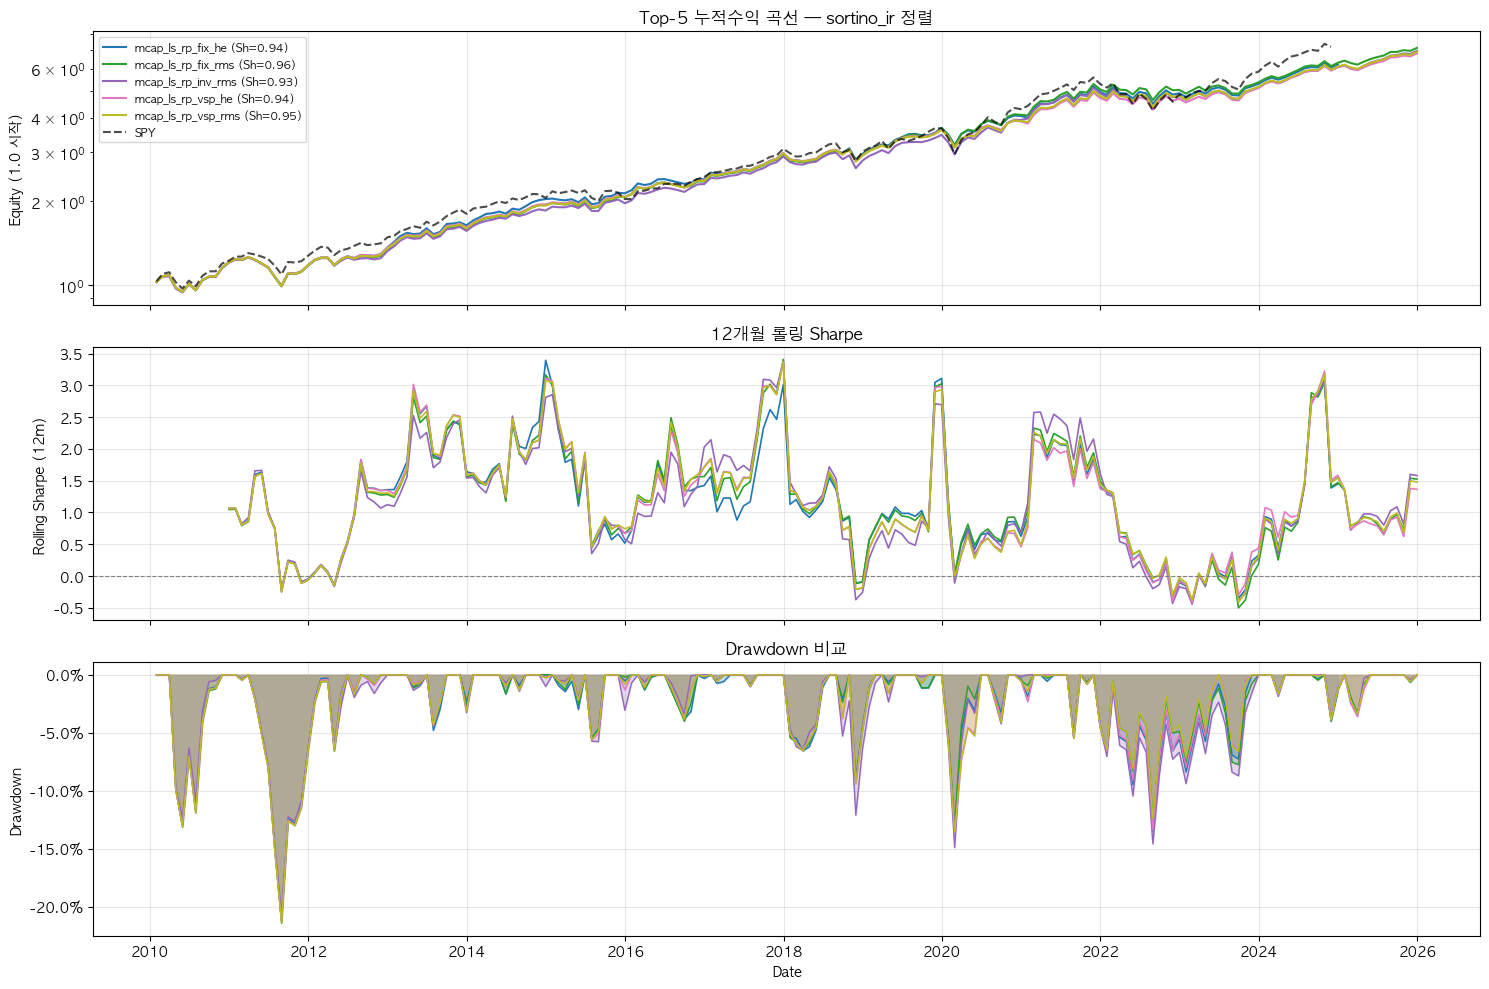

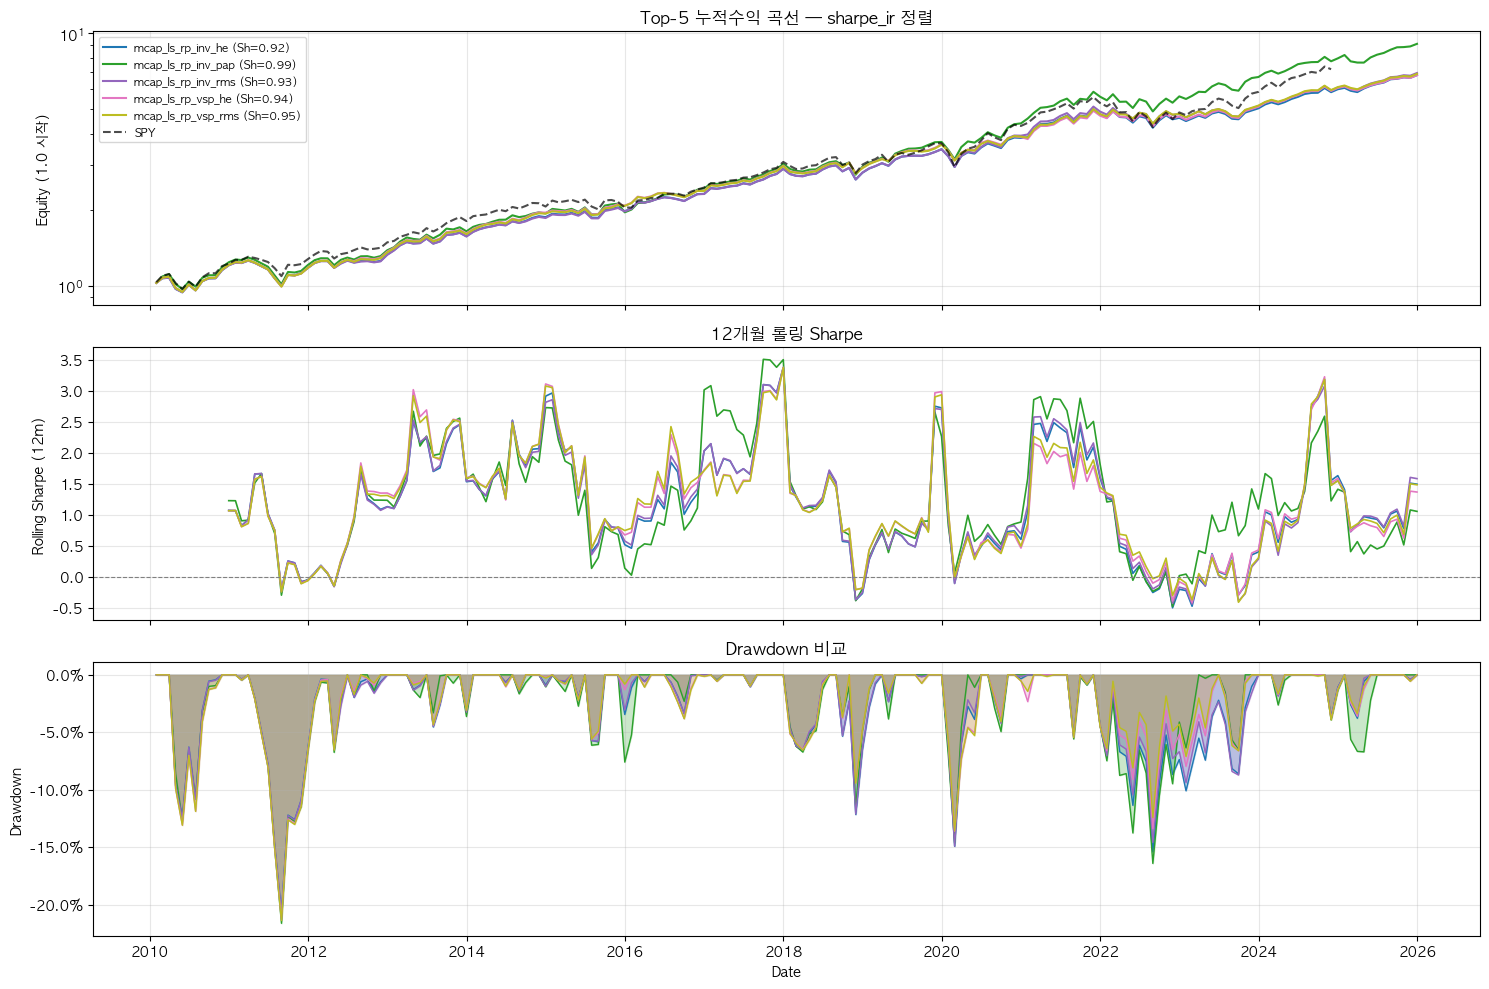

In [27]:
# ── J4. Top-N 정밀 분석 — sortino_ir / sharpe_ir 두 정렬로 시계열 비교 ────
# 무엇을 보나:
#   - Equity Curve: 180개월 누적수익 (vs SPY 점선)
#   - Rolling Sharpe: 12개월 롤링 Sharpe 시계열 (위기/회복 시점)
#   - Drawdown: 시간에 따른 손실 깊이
# → 히트맵(J3, K2)이 *집계* 메트릭이라면, J4는 *시계열 행동* 보여줌

# rt가 K1 이전 셀이므로 inline 빌드 (sortino_ir / sharpe_ir 컬럼 필요)
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from master_table import build_regime_table, REGIMES_5
from analyze_plots import plot_top_n_analysis

rt_j4 = build_regime_table(mt, RESULTS_DIR, rf, regimes=REGIMES_5)

# 두 정렬 키별 Top 5 후보 name 추출
top_sortino_ir = rt_j4.nlargest(5, 'sortino_ir')['name'].tolist()
top_sharpe_ir  = rt_j4.nlargest(5, 'sharpe_ir')['name'].tolist()

print('■ Sortino IR Top 5 (변동 대비 평균)')
display(rt_j4.nlargest(5, 'sortino_ir')[['canonical','sortino_ir','sortino_mean','sortino_std','sortino_min','mdd_worst']].round(3))

print('\n■ Sharpe IR Top 5')
display(rt_j4.nlargest(5, 'sharpe_ir')[['canonical','sharpe_ir','sharpe_mean','sharpe_std','sharpe_min','mdd_worst']].round(3))

# 두 정렬로 plot
print('\n=== J4-A. Sortino IR Top 5 시계열 ===')
plot_top_n_analysis(
    mt, RESULTS_DIR, spy_ret, rf,
    top_names=top_sortino_ir, rolling_window=12,
    title_suffix=' — sortino_ir 정렬',
    save_path=OUT_DIR / 'J4A_top5_sortino_ir.png',
)

print('\n=== J4-B. Sharpe IR Top 5 시계열 ===')
plot_top_n_analysis(
    mt, RESULTS_DIR, spy_ret, rf,
    top_names=top_sharpe_ir, rolling_window=12,
    title_suffix=' — sharpe_ir 정렬',
    save_path=OUT_DIR / 'J4B_top5_sharpe_ir.png',
)

# 교집합
inter = set(top_sortino_ir) & set(top_sharpe_ir)
print(f'\n■ 두 정렬 교집합 (Top 5 ∩ Top 5): {len(inter)}개')
for n in sorted(inter):
    canon = rt_j4[rt_j4.name == n].iloc[0]['canonical']
    print(f'  {n:<25} canonical={canon}')


In [28]:
# ── J5. 위기구간 행동 비교 ────────────────────────────────────
# 2018Q4 변동성 쇼크, 2020 COVID, 2022 인플레

cc = crisis_comparison(mt, RESULTS_DIR, n_top=5, spy_ret=spy_ret)
display(cc)


name  구간_누적수익  구간_MDD  \
구간           canonical                                                    
2018Q4_변동성쇼크 mcap_ls_eq_raw_pap    mat_mcap_eq_raw_pap   0.0099 -0.0640   
             mcap_ls_eq_lam_pap    mat_mcap_eq_lam_pap   0.0029 -0.0799   
             mcap_ls_eq_fix_pap    mat_mcap_eq_fix_pap  -0.0069 -0.1006   
             mcap_ls_eq_vsp_pap    mat_mcap_eq_vsp_pap  -0.0065 -0.1008   
             mcap_tr_mcap_fix_pap          omega_paper  -0.0492 -0.1062   
             SPY                                   SPY   0.0032 -0.0880   
2020_COVID   mcap_ls_eq_raw_pap    mat_mcap_eq_raw_pap   0.1408  0.0000   
             mcap_ls_eq_lam_pap    mat_mcap_eq_lam_pap   0.1420  0.0000   
             mcap_ls_eq_fix_pap    mat_mcap_eq_fix_pap   0.1050  0.0000   
             mcap_ls_eq_vsp_pap    mat_mcap_eq_vsp_pap   0.1008  0.0000   
             mcap_tr_mcap_fix_pap          omega_paper   0.0693  0.0000   
             SPY                                   SPY   0.0332  0.0000   
2022_인플레     mcap_ls_eq_raw_pap    mat_mcap_eq_raw_pap  -0.0012 -0.1339   
             mcap_ls_eq_lam_pap    mat_mcap_eq_lam_pap  -0.0012 -0.1339   
             mcap_ls_eq_fix_pap    mat_mcap_eq_fix_pap   0.0165 -0.1302   
             mcap_ls_eq_vsp_pap    mat_mcap_eq_vsp_pap   0.0184 -0.1290   
             mcap_tr_mcap_fix_pap          omega_paper   0.0814 -0.0939   
             SPY                                   SPY  -0.0834 -0.2025   

                                      최악월     최고월  월수  
구간           canonical                                 
2018Q4_변동성쇼크 mcap_ls_eq_raw_pap   -0.0640  0.0467   3  
             mcap_ls_eq_lam_pap   -0.0799  0.0606   3  
             mcap_ls_eq_fix_pap   -0.1006  0.0758   3  
             mcap_ls_eq_vsp_pap   -0.1008  0.0763   3  
             mcap_tr_mcap_fix_pap -0.1062  0.0351   3  
             SPY                  -0.0880  0.0801   3  
2020_COVID   mcap_ls_eq_raw_pap   -0.0291  0.1158   3  
             mcap_ls_eq_lam_pap   -0.0281  0.1159   3  
             mcap_ls_eq_fix_pap   -0.0610  0.1175   3  
             mcap_ls_eq_vsp_pap   -0.0635  0.1164   3  
             mcap_tr_mcap_fix_pap -0.0876  0.1137   3  
             SPY                  -0.1249  0.1270   3  
2022_인플레     mcap_ls_eq_raw_pap   -0.0943  0.0813  10  
             mcap_ls_eq_lam_pap   -0.0943  0.0813  10  
             mcap_ls_eq_fix_pap   -0.0867  0.0827  10  
             mcap_ls_eq_vsp_pap   -0.0868  0.0825  10  
             mcap_tr_mcap_fix_pap -0.0656  0.0887  10  
             SPY                  -0.0924  0.0921  10

In [29]:
# ── J6. 벤치마크 대비 IR 표 ──────────────────────────────────
# vs baseline / capm_no_bl / naive_lowvol / SPY
# IR > 0.4 = 의미 있는 부가가치

bt = benchmark_table(mt, RESULTS_DIR, spy_ret, rf, n_top=10)

# IR 컬럼만 보기
ir_cols = ['name','sharpe'] + [c for c in bt.columns if c.endswith('_IR')]
display(bt[ir_cols].round(3))

print('\n=== 평균 IR (벤치마크 대비) ===')
for col in [c for c in bt.columns if c.endswith('_IR')]:
    print(f'  {col:25s}: {bt[col].mean():.3f}')


,name,sharpe,baseline_IR,capm_no_bl_IR,naive_lowvol_IR,SPY_IR
canonical,,,,,,
mcap_ls_eq_raw_pap,mat_mcap_eq_raw_pap,1.144,0.455,0.185,0.348,0.241
mcap_ls_eq_lam_pap,mat_mcap_eq_lam_pap,1.140,0.468,0.198,0.364,0.253
mcap_ls_eq_fix_pap,mat_mcap_eq_fix_pap,1.121,0.448,0.195,0.376,0.259
mcap_ls_eq_vsp_pap,mat_mcap_eq_vsp_pap,1.120,0.433,0.187,0.374,0.252
mcap_tr_mcap_fix_pap,omega_paper,1.120,0.439,0.180,0.411,0.228
mcap_ls_eq_inv_pap,mat_mcap_eq_inv_pap,1.119,0.429,0.193,0.393,0.266
mcap_tr_mcap_fix_he,baseline,1.106,NaN,-0.161,-0.146,-0.128
eq_tr_mcap_fix_he,prior_eq,1.105,0.304,-0.064,0.086,-0.032
eq_ls_eq_raw_pap,mat_eq_eq_raw_pap,1.103,0.463,0.212,0.367,0.264



=== 평균 IR (벤치마크 대비) ===
  baseline_IR              : 0.434
  capm_no_bl_IR            : 0.135
  naive_lowvol_IR          : 0.295
  SPY_IR                   : 0.188


## K. 레짐 안정성 분석 — Sortino + 5-레짐 변동성 ⭐

### 왜 이 분석이 필요한가
- **Sharpe보다 Sortino가 본 프로젝트에 더 적합**: 저위험 anomaly 컨셉 → 하방 변동성만이 진짜 손실 위험
- **레짐별 일관성**: 한 시기만 강한 후보는 운. 5개 레짐 모두에서 일관되게 좋은 후보를 찾아야 함
- **MDD 안정성**: 위기 레짐에서 MDD 폭증하는 후보 제외

### 5-레짐 정의 (김윤서/low_risk/regime_analysis.py 기준)

| 레짐 | 기간 | 개월 | 환경 |
|---|---|---:|---|
| R1 회복 | 2010-2014 | 60 | Post-GFC + 유럽위기 |
| R2 확장 | 2015-2018 | 48 | 미국 회복 + 다중충격 |
| R3 COVID | 2019-2020 | 24 | 코로나 크래시 + 회복 |
| R4 베어 | 2021-2022 | 24 | 인플레 + 22년 베어 |
| R5 AI 랠리 | 2023-2024 | 24 | Mag7 강세 |

### 핵심 지표 (build_regime_table 출력)
- `sortino_R1..R5`: 레짐별 Sortino
- `sortino_mean`: 5 레짐 평균
- `sortino_std`: 5 레짐 표준편차 (**낮을수록 안정**)
- `sortino_min`: worst-case Sortino
- `mdd_worst`: 5 레짐 중 가장 깊은 MDD
- **`stability_score = sortino_mean − sortino_std`**: 안정성+평균 종합 (정렬 키)


In [30]:
# ── K1. 레짐 테이블 빌드 + 4-view 정렬 + 핵심 비교군 4종 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
import numpy as np, pickle

from master_table import build_regime_table, REGIMES_5, regime_metrics
from analyze_plots import plot_regime_heatmap, regime_winners_table

rt = build_regime_table(mt, RESULTS_DIR, rf, regimes=REGIMES_5)
print(f'레짐 테이블: {len(rt)}개 실험 × {rt.shape[1]}개 컬럼')

# ── 핵심 비교군 4종 5-레짐 종합 메트릭 ─────────────────────────
def _calc_ref(label, ret_series, rf, regimes):
    sortinos, mdds = [], []
    rec = {'canonical': label}
    for lbl, s, e in regimes:
        m = regime_metrics(ret_series, rf, s, e)
        if not np.isnan(m['sortino']): sortinos.append(m['sortino'])
        mdds.append(m['mdd'])
    rec['sortino_mean']    = round(np.mean(sortinos), 3) if sortinos else np.nan
    rec['sortino_std']     = round(np.std(sortinos),  3) if sortinos else np.nan
    rec['sortino_min']     = round(np.min(sortinos),  3) if sortinos else np.nan
    rec['mdd_worst']       = round(np.min(mdds),      3) if mdds else np.nan
    rec['stability_score'] = round(np.mean(sortinos) - np.std(sortinos), 3) if sortinos else np.nan
    return rec

def _load_ret(name):
    with open(RESULTS_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

baseline_ret    = _load_ret('baseline')
capm_no_bl_ret  = _load_ret('capm_no_bl')
naive_lowvol_ret= _load_ret('naive_lowvol')

ref_rows = [
    _calc_ref('SPY (시장 패시브)',     spy_ret,          rf, REGIMES_5),
    _calc_ref('baseline (표준 BL)',   baseline_ret,     rf, REGIMES_5),
    _calc_ref('capm_no_bl (BL 없음)', capm_no_bl_ret,   rf, REGIMES_5),
    _calc_ref('naive_lowvol (단순)',  naive_lowvol_ret, rf, REGIMES_5),
]

view_cols = ['canonical','sortino_min','sortino_mean','sortino_std','mdd_worst','stability_score','sharpe']

print('\n■ 핵심 비교군 4종 — 5-레짐 종합')
display(pd.DataFrame([{k: r.get(k, np.nan) for k in view_cols} for r in ref_rows]).round(3))

# ── 비교군 레짐별 상세 (Sortino / Sharpe / MDD) ─────────────────
benchmarks_list = [('SPY', spy_ret), ('baseline', baseline_ret),
                   ('capm_no_bl', capm_no_bl_ret), ('naive_lowvol', naive_lowvol_ret)]

print('\n■ 비교군 4종 레짐별 상세 — Sortino / Sharpe / MDD')

for metric_key, metric_label in [('sortino','Sortino'), ('sharpe','Sharpe'), ('mdd','MDD')]:
    print(f'\n[ {metric_label} per 레짐 ]')
    rows = []
    for name, ret in benchmarks_list:
        rec = {'benchmark': name}
        for lbl, s, e in REGIMES_5:
            v = regime_metrics(ret, rf, s, e)[metric_key]
            rec[lbl] = v if not pd.isna(v) else np.nan
        rows.append(rec)
    df_m = pd.DataFrame(rows).set_index('benchmark')
    if metric_key == 'mdd':
        display(df_m.style.format('{:.2%}'))
    else:
        display(df_m.round(3))

# ── 4가지 정렬 관점 (각각 Top 5) ─────────────────────────────
print('\n■ ① sortino_min 정렬 [메인]  (5 레짐 중 가장 나쁜 레짐의 Sortino 최고)')
display(rt.nlargest(5, 'sortino_min')[view_cols].round(3))

print('\n■ ② sortino_mean 정렬  (5 레짐 평균 Sortino 최고)')
display(rt.nlargest(5, 'sortino_mean')[view_cols].round(3))

print('\n■ ③ stability_score 정렬 [보조]  (mean − std)')
display(rt.nlargest(5, 'stability_score')[view_cols].round(3))

print('\n■ ④ Sortino IR 정렬  (mean / std, 변동 대비 평균)')
rt2 = rt.copy()
rt2['sortino_ir'] = rt2['sortino_mean'] / rt2['sortino_std'].replace(0, np.nan)
display(rt2.nlargest(5, 'sortino_ir')[view_cols + ['sortino_ir']].round(3))


레짐 테이블: 175개 실험 × 56개 컬럼

■ 핵심 비교군 4종 — 5-레짐 종합


,canonical,sortino_min,sortino_mean,sortino_std,mdd_worst,stability_score,sharpe
0,SPY (시장 패시브),0.713,1.700,1.011,-0.239,0.688,NaN
1,baseline (표준 BL),0.657,1.726,0.839,-0.130,0.886,NaN
2,capm_no_bl (BL 없음),0.760,1.600,0.796,-0.222,0.804,NaN
3,naive_lowvol (단순),0.850,1.494,0.556,-0.147,0.938,NaN



■ 비교군 4종 레짐별 상세 — Sortino / Sharpe / MDD

[ Sortino per 레짐 ]


,R1_회복,R2_확장,R3_COVID,R4_베어,R5_AI랠리
benchmark,,,,,
SPY,1.887,1.059,1.266,0.713,3.572
baseline,2.496,1.042,2.865,1.569,0.657
capm_no_bl,1.621,0.760,1.345,1.183,3.091
naive_lowvol,2.342,0.911,1.689,1.680,0.850



[ Sharpe per 레짐 ]


...

,canonical,sortino_min,sortino_mean,sortino_std,mdd_worst,stability_score,sharpe
28,eq_ls_mcap_raw_rms,0.227,2.390,2.008,-0.130,0.382,1.043
118,rp_ls_mcap_raw_rms,0.127,2.329,1.921,-0.132,0.408,1.031
165,eq_tr_mcap_raw_he,0.114,2.302,1.838,-0.127,0.465,1.057
162,eq_tr_mcap_lam_he,0.114,2.282,1.831,-0.114,0.452,1.054
25,eq_ls_mcap_lam_rms,0.227,2.270,1.927,-0.123,0.343,1.014



■ ③ stability_score 정렬 [보조]  (mean − std)


,canonical,sortino_min,sortino_mean,sortino_std,mdd_worst,stability_score,sharpe
60,mcap_ls_eq_vsp_pap,1.023,1.928,0.509,-0.132,1.419,1.120
48,mcap_ls_eq_fix_pap,0.962,1.913,0.526,-0.132,1.387,1.121
51,mcap_ls_eq_inv_pap,0.973,1.835,0.490,-0.147,1.345,1.119
57,mcap_ls_eq_raw_pap,1.114,2.010,0.683,-0.147,1.327,1.144
54,mcap_ls_eq_lam_pap,1.049,1.996,0.709,-0.147,1.287,1.140



■ ④ Sortino IR 정렬  (mean / std, 변동 대비 평균)


,canonical,sortino_min,sortino_mean,sortino_std,mdd_worst,stability_score,sharpe,sortino_ir
91,mcap_ls_rp_vsp_rms,1.179,1.360,0.132,-0.214,1.228,0.948,10.303
77,mcap_ls_rp_fix_he,1.115,1.376,0.195,-0.212,1.181,0.942,7.056
79,mcap_ls_rp_fix_rms,1.184,1.380,0.210,-0.214,1.170,0.957,6.571
82,mcap_ls_rp_inv_rms,1.090,1.383,0.221,-0.207,1.163,0.925,6.258
89,mcap_ls_rp_vsp_he,1.128,1.419,0.302,-0.213,1.117,0.940,4.699


■ 레짐별 Sortino — 핵심 비교군 4종
레짐               SPY   baseline   capm_no_bl   naive_low
--------------------------------------------------------
R1_회복           1.89       2.50         1.62        2.34
R2_확장           1.06       1.04         0.76        0.91
R3_COVID        1.27       2.86         1.35        1.69
R4_베어           0.71       1.57         1.18        1.68
R5_AI랠리         3.57       0.66         3.09        0.85


=== K2-A. Sortino IR 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-A 행 매핑 (sortino_ir 큰 순)


,canonical,sortino_ir,sortino_mean,sortino_min,sortino_std,mdd_worst,sharpe
1,mcap_ls_rp_vsp_rms,10.30,1.360,1.179,0.132,-0.214,0.948
2,mcap_ls_rp_fix_he,7.06,1.376,1.115,0.195,-0.212,0.942
3,mcap_ls_rp_fix_rms,6.57,1.380,1.184,0.210,-0.214,0.957
4,mcap_ls_rp_inv_rms,6.26,1.383,1.090,0.221,-0.207,0.925
5,mcap_ls_rp_vsp_he,4.70,1.419,1.128,0.302,-0.213,0.940
6,mcap_ls_rp_inv_he,4.42,1.402,1.065,0.317,-0.207,0.916
7,mcap_ls_eq_vsp_pap,3.79,1.928,1.023,0.509,-0.132,1.120
8,mcap_ls_eq_inv_pap,3.74,1.835,0.973,0.490,-0.147,1.119
9,eq_ls_rp_inv_pap,3.65,1.506,0.964,0.413,-0.206,0.977
10,mcap_ls_eq_fix_pap,3.64,1.913,0.962,0.526,-0.132,1.121




=== K2-B. 핵심 비교군 대비 레짐 우위 카운트 ===
1순위: SPY (액티브 펀드 출시 기준) / 2순위: naive_lowvol (USMV 카테고리)

■ SPY 대비 우위 레짐 수 Top 10


,canonical,n_beat_SPY,n_beat_naive_lowvol,n_beat_baseline,n_beat_capm_no_bl,sortino_mean,sortino_min,mdd_worst,sharpe
1,eq_tr_mcap_raw_he,4,4,4,4,2.302,0.114,-0.127,1.057
2,eq_tr_mcap_lam_he,4,4,4,4,2.282,0.114,-0.114,1.054
3,eq_tr_volm_fix_he,4,4,4,4,2.216,-0.093,-0.108,1.030
4,mcap_tr_mcap_raw_he,4,4,3,4,2.057,0.336,-0.123,1.076
5,mcap_tr_mcap_lam_he,4,4,3,4,2.020,0.336,-0.107,1.067
6,mcap_ls_eq_raw_pap,4,3,3,4,2.010,1.114,-0.147,1.144
7,eq_ls_eq_raw_pap,4,5,4,4,1.867,0.987,-0.136,1.103
8,rp_ls_eq_raw_pap,4,5,5,4,1.857,0.857,-0.132,1.098
9,eq_ls_eq_raw_rms,4,3,3,4,1.854,0.032,-0.151,0.942
10,rp_ls_eq_raw_he,4,3,3,4,1.831,0.052,-0.152,0.943



■ n_beat_SPY 분포 (전체)
n_beat_SPY
1      4
2     37
3    109
4     25


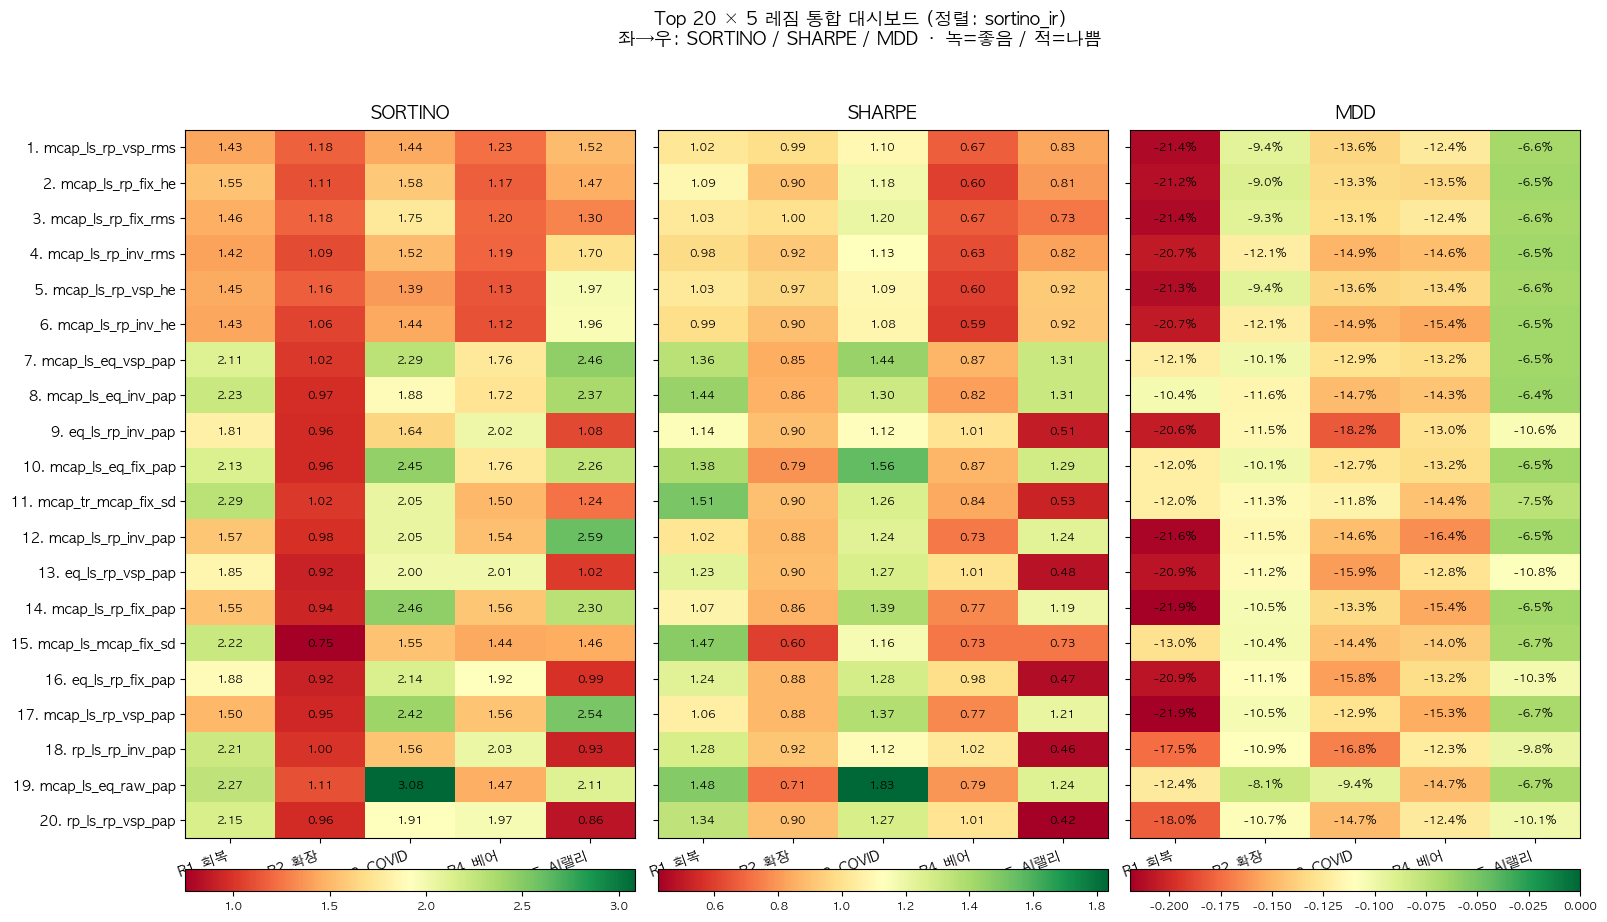

In [31]:
# ── K2. Sortino IR Top 20 통합 대시보드 + 비교군 우위 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

# rt가 K1에서 build됐다고 가정. composite_rank 제거되었으니 다시 빌드.
from master_table import build_regime_table, REGIMES_5
rt = build_regime_table(mt, RESULTS_DIR, rf, regimes=REGIMES_5)

# 비교군 5-레짐 sortino
print('■ 레짐별 Sortino — 핵심 비교군 4종')
print(f'{"레짐":<12} {"SPY":>7} {"baseline":>10} {"capm_no_bl":>12} {"naive_low":>11}')
print('-' * 56)
bench_sortinos = {'SPY': {}, 'baseline': {}, 'capm_no_bl': {}, 'naive_lowvol': {}}
for lbl, s, e in REGIMES_5:
    sm = regime_metrics(spy_ret,           rf, s, e)['sortino']
    bm = regime_metrics(baseline_ret,      rf, s, e)['sortino']
    cm = regime_metrics(capm_no_bl_ret,    rf, s, e)['sortino']
    nm = regime_metrics(naive_lowvol_ret,  rf, s, e)['sortino']
    bench_sortinos['SPY'][lbl]          = sm
    bench_sortinos['baseline'][lbl]     = bm
    bench_sortinos['capm_no_bl'][lbl]   = cm
    bench_sortinos['naive_lowvol'][lbl] = nm
    print(f'{lbl:<12} {sm:>7.2f} {bm:>10.2f} {cm:>12.2f} {nm:>11.2f}')

# ── K2-A. Sortino IR Top 20 — 3 metric × 5 레짐 통합 대시보드 (PNG) ─
print('\n\n=== K2-A. Sortino IR 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sortino_ir', top_n=20,
    save_path=OUT_DIR / 'K2A_sortino_ir_dashboard.png',
)

# 행 매핑 표
top20 = rt.nlargest(20, 'sortino_ir').reset_index(drop=True); top20.index += 1
print('\n■ K2-A 행 매핑 (sortino_ir 큰 순)')
display(top20[['canonical','sortino_ir','sortino_mean','sortino_min','sortino_std','mdd_worst','sharpe']].round(3))

# ── K2-B. 비교군 우위 카운트 ──────────────────────────────────
print('\n\n=== K2-B. 핵심 비교군 대비 레짐 우위 카운트 ===')
print('1순위: SPY (액티브 펀드 출시 기준) / 2순위: naive_lowvol (USMV 카테고리)')

import numpy as np
rt_beat = rt.copy()
for bname in ['SPY','baseline','capm_no_bl','naive_lowvol']:
    bs = bench_sortinos[bname]
    counts = []
    for _, row in rt_beat.iterrows():
        n = sum(1 for lbl,_,_ in REGIMES_5
                if pd.notna(row[f'sortino_{lbl}']) and pd.notna(bs[lbl]) and row[f'sortino_{lbl}'] > bs[lbl])
        counts.append(n)
    rt_beat[f'n_beat_{bname}'] = counts

print('\n■ SPY 대비 우위 레짐 수 Top 10')
top_beat = rt_beat.sort_values(['n_beat_SPY','sortino_mean'], ascending=[False, False]).head(10).reset_index(drop=True)
top_beat.index += 1
display(top_beat[['canonical','n_beat_SPY','n_beat_naive_lowvol','n_beat_baseline','n_beat_capm_no_bl',
                  'sortino_mean','sortino_min','mdd_worst','sharpe']].round(3))

print('\n■ n_beat_SPY 분포 (전체)')
print(rt_beat['n_beat_SPY'].value_counts().sort_index().to_string())


## K2-H. Sharpe IR 정렬 Top 20 × 3 metric 히트맵

`sortino_ir`(mean/std) 기준 정렬과 별개로 **`sharpe_ir = sharpe_mean / sharpe_std`** 기준으로 Top 20 추출.
3 metric (sortino, sharpe, mdd) per 레짐 히트맵으로 시각화.

→ Sortino 안정성 측면(K2-B)과 Sharpe 안정성 측면(여기) 둘 다 비교 가능.


=== K2-H. Sharpe IR 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-H 행 매핑 (sharpe_ir 큰 순)


,canonical,sharpe_ir,sharpe_mean,sharpe_min,sortino_ir,mdd_worst
1,mcap_ls_rp_vsp_rms,6.07,0.922,0.673,10.30,-0.214
2,mcap_ls_rp_inv_rms,5.44,0.897,0.633,6.26,-0.207
3,mcap_ls_rp_vsp_he,5.40,0.923,0.600,4.70,-0.213
4,mcap_ls_rp_inv_he,5.33,0.896,0.587,4.42,-0.207
5,mcap_ls_rp_inv_pap,5.13,1.020,0.731,3.22,-0.216
6,mcap_ls_rp_vsp_pap,4.83,1.057,0.766,2.98,-0.219
7,mcap_ls_rp_fix_pap,4.74,1.057,0.766,3.18,-0.219
8,mcap_ls_rp_fix_rms,4.67,0.924,0.670,6.57,-0.214
9,mcap_ls_eq_vsp_pap,4.62,1.168,0.852,3.79,-0.132
10,mcap_ls_rp_fix_he,4.47,0.917,0.602,7.06,-0.212



■ Sortino IR Top 20 ∩ Sharpe IR Top 20 = 두 측면 모두 강한 후보
  교집합: 16개


,canonical,sortino_ir,sharpe_ir,sortino_mean,sortino_min,mdd_worst,sharpe
91,mcap_ls_rp_vsp_rms,10.30,6.07,1.360,1.179,-0.214,0.948
77,mcap_ls_rp_fix_he,7.06,4.47,1.376,1.115,-0.212,0.942
79,mcap_ls_rp_fix_rms,6.57,4.67,1.380,1.184,-0.214,0.957
82,mcap_ls_rp_inv_rms,6.26,5.44,1.383,1.090,-0.207,0.925
89,mcap_ls_rp_vsp_he,4.70,5.40,1.419,1.128,-0.213,0.940
80,mcap_ls_rp_inv_he,4.42,5.33,1.402,1.065,-0.207,0.916
60,mcap_ls_eq_vsp_pap,3.79,4.62,1.928,1.023,-0.132,1.120
51,mcap_ls_eq_inv_pap,3.74,4.46,1.835,0.973,-0.147,1.119
36,eq_ls_rp_inv_pap,3.65,4.07,1.506,0.964,-0.206,0.977
48,mcap_ls_eq_fix_pap,3.64,3.95,1.913,0.962,-0.132,1.121


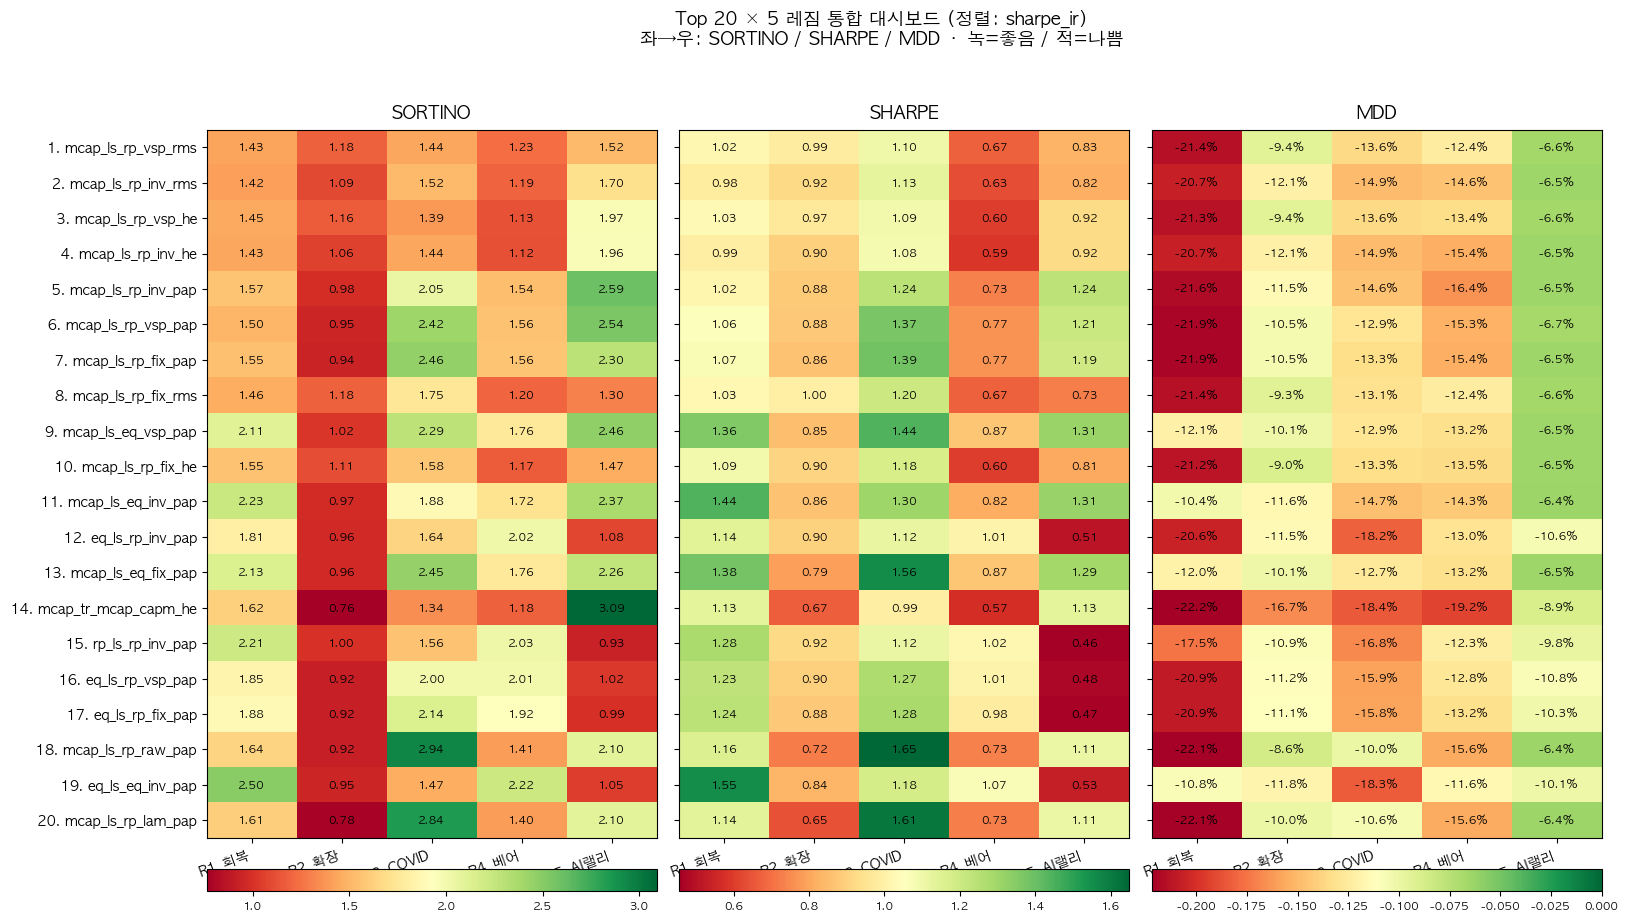

In [32]:
# ── K2-H. Sharpe IR Top 20 통합 대시보드 + 두 IR 교집합 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

print('=== K2-H. Sharpe IR 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sharpe_ir', top_n=20,
    save_path=OUT_DIR / 'K2H_sharpe_ir_dashboard.png',
)

top20_sh = rt.nlargest(20, 'sharpe_ir').reset_index(drop=True); top20_sh.index += 1
print('\n■ K2-H 행 매핑 (sharpe_ir 큰 순)')
display(top20_sh[['canonical','sharpe_ir','sharpe_mean','sharpe_min','sortino_ir','mdd_worst']].round(3))

# Sortino IR ∩ Sharpe IR Top 20 교집합
print('\n■ Sortino IR Top 20 ∩ Sharpe IR Top 20 = 두 측면 모두 강한 후보')
set_so = set(rt.nlargest(20, 'sortino_ir')['canonical'])
set_sh = set(top20_sh['canonical'])
inter = set_so & set_sh
print(f'  교집합: {len(inter)}개')
if inter:
    display(rt[rt['canonical'].isin(inter)].sort_values('sortino_ir', ascending=False)
              [['canonical','sortino_ir','sharpe_ir','sortino_mean','sortino_min','mdd_worst','sharpe']]
              .round(3))


■ 레짐별 MDD — 핵심 비교군 4종
레짐                 SPY   baseline   capm_no_bl   naive_low
-------------------------------------------------------
R1_회복          -16.22%     -9.69%      -22.19%     -10.57%
R2_확장          -13.53%     -9.27%      -16.70%     -13.61%
R3_COVID       -19.45%     -9.20%      -18.37%     -12.44%
R4_베어          -23.93%    -13.03%      -19.17%     -14.73%
R5_AI랠리         -8.33%     -6.91%       -8.91%      -8.81%

■ K3 히트맵 행 매핑 (mdd_worst 얕은 순)


,canonical,mdd_worst,sortino_min,sortino_mean,stability_score
1,mcap_tr_volm_fix_he,-0.102,-0.060,1.803,0.543
2,mcap_ls_mcap_fix_sh,-0.103,0.582,1.593,0.713
3,mcap_tr_volm_lam_he,-0.106,-0.271,1.552,0.342
4,mcap_tr_mcap_lam_he,-0.107,0.336,2.020,0.594
5,eq_tr_volm_fix_he,-0.108,-0.093,2.216,0.359
6,mcap_ls_mcap_lam_he,-0.110,0.711,2.042,0.555
7,rp_ls_mcap_lam_he,-0.111,0.201,2.168,0.448
8,eq_tr_volm_lam_he,-0.111,-0.286,1.585,0.373
9,mcap_ls_mcap_lam_rms,-0.112,0.620,2.093,0.475
10,rp_ls_mcap_lam_rms,-0.112,0.127,2.257,0.341


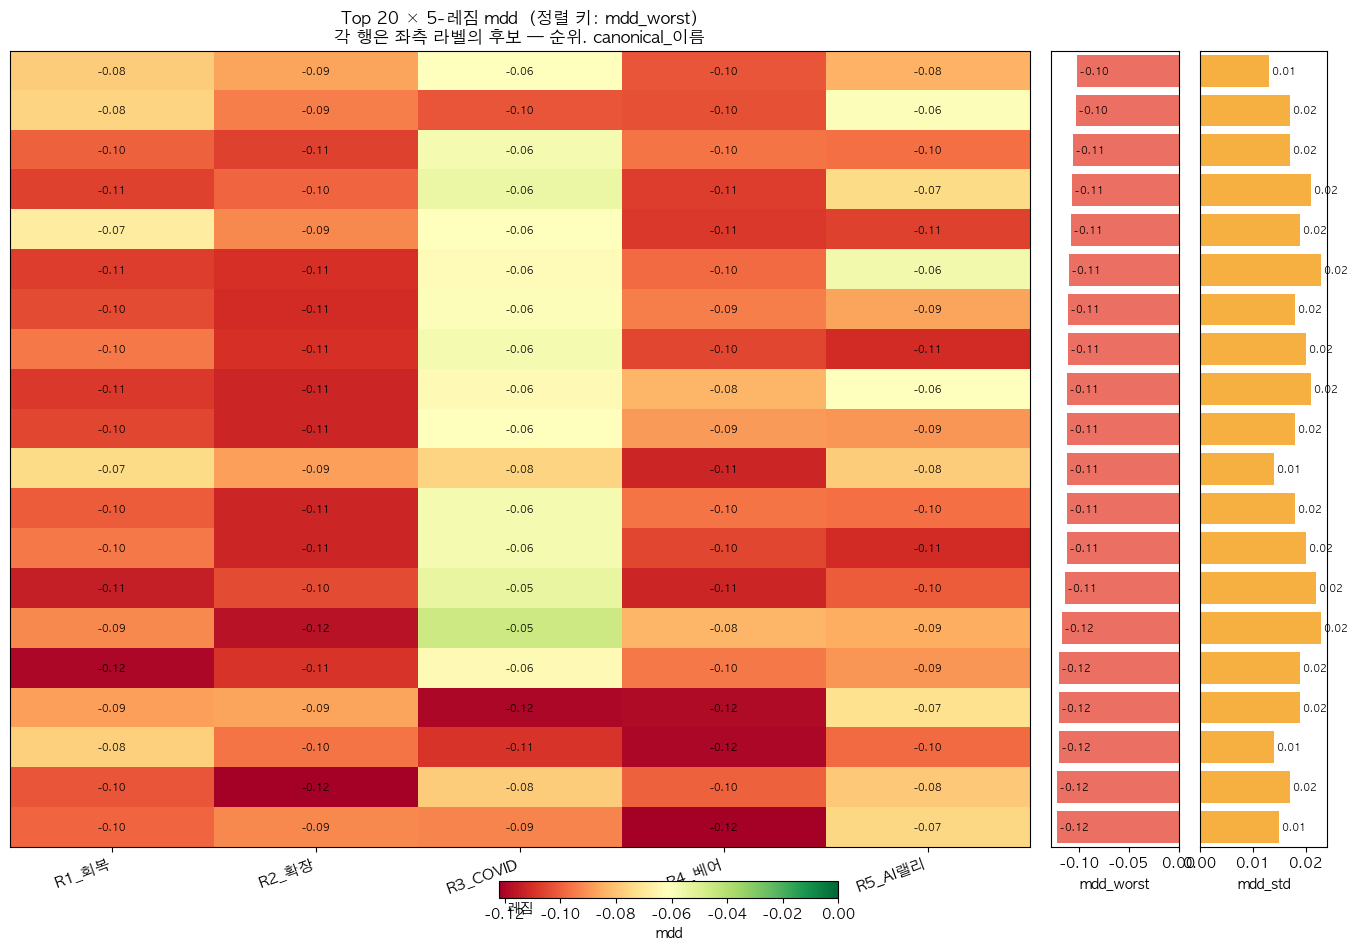

In [33]:
# ── K3. MDD 5-레짐 히트맵 + 비교군 MDD + 행 매핑표 ──────────
# 정렬: mdd_worst (5 레짐 중 가장 깊은 MDD가 얕은 순)

print('■ 레짐별 MDD — 핵심 비교군 4종')
print(f'{"레짐":<12} {"SPY":>9} {"baseline":>10} {"capm_no_bl":>12} {"naive_low":>11}')
print('-' * 55)
for lbl, s, e in REGIMES_5:
    sm = regime_metrics(spy_ret,           rf, s, e)['mdd']
    bm = regime_metrics(baseline_ret,      rf, s, e)['mdd']
    cm = regime_metrics(capm_no_bl_ret,    rf, s, e)['mdd']
    nm = regime_metrics(naive_lowvol_ret,  rf, s, e)['mdd']
    print(f'{lbl:<12} {sm:>9.2%} {bm:>10.2%} {cm:>12.2%} {nm:>11.2%}')

_ = plot_regime_heatmap(
    rt, metric='mdd', top_n=20, rank_by='mdd_worst',
    save_path=OUT_DIR / 'K3_regime_mdd_heatmap.png',
)

print('\n■ K3 히트맵 행 매핑 (mdd_worst 얕은 순)')
top20m = rt.nlargest(20, 'mdd_worst').reset_index(drop=True)
top20m.index += 1
display(top20m[['canonical','mdd_worst','sortino_min','sortino_mean','stability_score']].round(3))


In [34]:
# ── K5. 레짐별 위너 + 종합 위너 ──────────────────────────────
# 각 레짐의 Sortino Top 5 + 종합 안정성 Top 5

winners = regime_winners_table(rt, n=5)
for label, df in winners.items():
    print(f'\n[{label}]')
    display(df.round(3))



[R1_회복]


,canonical,sortino,mdd
0,rp_ls_eq_inv_rms,3.289,-0.054
1,eq_ls_eq_inv_he,3.277,-0.056
2,eq_ls_eq_inv_rms,3.258,-0.057
3,rp_ls_eq_inv_he,3.256,-0.054
4,rp_ls_mcap_inv_rms,3.256,-0.066



[R2_확장]


,canonical,sortino,mdd
0,mcap_ls_rp_raw_he,1.509,-0.086
1,mcap_ls_rp_raw_rms,1.500,-0.085
2,eq_ls_rp_raw_he,1.488,-0.089
3,eq_ls_rp_raw_rms,1.456,-0.089
4,rp_ls_rp_raw_he,1.454,-0.090



[R3_COVID]


...

,canonical,sortino,mdd
0,mcap_tr_mcap_fix_pap,2.911,-0.094
1,mcap_ls_mcap_fix_pap,2.704,-0.111
2,mcap_ls_mcap_vsp_pap,2.532,-0.117
3,eq_ls_mcap_vsp_pap,2.490,-0.104
4,mcap_ls_mcap_raw_pap,2.475,-0.102



[R5_AI랠리]


,canonical,sortino,mdd
0,mcap_tr_mcap_capm_he,3.091,-0.089
1,mcap_ls_rp_inv_pap,2.594,-0.065
2,mcap_ls_rp_vsp_pap,2.544,-0.067
3,mcap_ls_eq_vsp_pap,2.463,-0.065
4,mcap_ls_eq_inv_pap,2.370,-0.064



[stability_overall]


,canonical,sortino_mean,sortino_std,sortino_min,mdd_worst,stability_score
0,mcap_ls_eq_vsp_pap,1.928,0.509,1.023,-0.132,1.419
1,mcap_ls_eq_fix_pap,1.913,0.526,0.962,-0.132,1.387
2,mcap_ls_eq_inv_pap,1.835,0.490,0.973,-0.147,1.345
3,mcap_ls_eq_raw_pap,2.010,0.683,1.114,-0.147,1.327
4,mcap_ls_eq_lam_pap,1.996,0.709,1.049,-0.147,1.287


In [35]:
# ── K6. 위험성향별 최종 매핑 (레짐 안정성 기반) ──────────────
# 공격형: 평균 Sortino 최고
# 중립형: stability_score 최고 (mean − std)
# 안정형: mdd_worst 가장 얕음 + sortino_min ≥ 0

print('■ 공격형 (5-레짐 평균 Sortino 최고)')
display(rt.nlargest(3, 'sortino_mean')
        [['canonical','sortino_mean','sortino_std','sortino_min','mdd_worst','sharpe']]
        .round(3))

print('\n■ 중립형 (stability_score 최고 = 평균 − 변동)')
display(rt.nlargest(3, 'stability_score')
        [['canonical','sortino_mean','sortino_std','sortino_min','mdd_worst','sharpe']]
        .round(3))

print('\n■ 안정형 (mdd_worst 가장 얕음, sortino_min > 0)')
safe = rt[rt['sortino_min'] > 0].nlargest(3, 'mdd_worst')
display(safe[['canonical','sortino_mean','sortino_std','sortino_min','mdd_worst','sharpe']]
        .round(3))


■ 공격형 (5-레짐 평균 Sortino 최고)


,canonical,sortino_mean,sortino_std,sortino_min,mdd_worst,sharpe
28,eq_ls_mcap_raw_rms,2.390,2.008,0.227,-0.130,1.043
118,rp_ls_mcap_raw_rms,2.329,1.921,0.127,-0.132,1.031
165,eq_tr_mcap_raw_he,2.302,1.838,0.114,-0.127,1.057



■ 중립형 (stability_score 최고 = 평균 − 변동)


,canonical,sortino_mean,sortino_std,sortino_min,mdd_worst,sharpe
60,mcap_ls_eq_vsp_pap,1.928,0.509,1.023,-0.132,1.120
48,mcap_ls_eq_fix_pap,1.913,0.526,0.962,-0.132,1.121
51,mcap_ls_eq_inv_pap,1.835,0.490,0.973,-0.147,1.119



■ 안정형 (mdd_worst 가장 얕음, sortino_min > 0)


,canonical,sortino_mean,sortino_std,sortino_min,mdd_worst,sharpe
143,mcap_ls_mcap_fix_sh,1.593,0.880,0.582,-0.103,0.983
173,mcap_tr_mcap_lam_he,2.020,1.426,0.336,-0.107,1.067
68,mcap_ls_mcap_lam_he,2.042,1.488,0.711,-0.110,1.022
